In [3]:
from google.colab import drive
import os
import torch
import itertools
import pandas as pd
import numpy as np
from datasets import Dataset
import re
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [2]:
!pip install -q xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 26.9 MB/s eta 0:00:00


In [4]:
# Google Drive'ı bağla
drive.mount('/content/drive')
kayit_klasoru = '/content/drive/MyDrive/Hesaplamalı Anlambilim/Final_Project'

Mounted at /content/drive


### 1) Veri Seti Hazırlama

In [ ]:
print("Veri seti indiriliyor...")
full_dataset = load_dataset("ytu-ce-cosmos/gsm8k_tr", split="train")

def keep_clean_answers(example):
    answer_text = example['answer']
    question_text = example['question']

    # 1. Mevcut kurallar (hem answer hem question için geçerli olacaklar)
    combined_text = (answer_text + " " + question_text).lower()

    # 1. Para Birimi Kontrolü
    yasakli_semboller = ['$', '€', '£', '¥', '₺']
    para_birimi_var = any(sembol in answer_text for sembol in yasakli_semboller)

    # 2. LaTeX / Blok Matematik Formatı Kontrolü
    formatli_mat_var = '\\[' in answer_text or '\\]' in answer_text

    # 3. Küsuratlı Sayı ve Binlik Ayraç Kontrolü (126.98, 571,000 vb.)
    kusurat_veya_binlik_var = bool(re.search(r'\d+[.,]\d+', answer_text))

    # 4. Saat/Zaman Formatı Kontrolü (Örn: 08:30, 14:45, 9:00)
    zaman_formati_var = bool(re.search(r'\d{1,2}:\d{2}', answer_text))

    # 6. GÜNCEL YÜZDE KONTROLÜ: Hem soru hem cevapta arıyoruz
    yuzde_var = '%' in combined_text or 'yüzde' in combined_text

    # 5. Son Cümlede Rakam Yoksa (Yazıyla yazılmışsa) Eleme Kuralı
    satirlar = [s.strip() for s in answer_text.split('\n') if s.strip()]
    son_satir = satirlar[-1] if satirlar else ""
    cumleler = [c.strip() for c in son_satir.split('. ') if c.strip()]
    son_cumle = cumleler[-1] if cumleler else ""

    # Eğer son cümlenin içinde hiçbir rakam (\d) yoksa True döner (istenmeyen durum)
    son_cumlede_rakam_yok = not bool(re.search(r'\d+', son_cumle))

    # İstenmeyen hiçbir durum YOKSA True dön (veriyi veri setinde tut)
    return not (para_birimi_var or formatli_mat_var or kusurat_veya_binlik_var or
                zaman_formati_var or son_cumlede_rakam_yok or yuzde_var)

print("Filtreleniyor...")
# Tüm veri setine filtreyi uyguluyoruz
clean_full_dataset = full_dataset.filter(keep_clean_answers)

# 2. Temizlenmiş veri seti üzerinden senin kuralına göre dilimleme (Slicing) işlemi
train_dataset = clean_full_dataset.select(range(3000))
test_dataset = clean_full_dataset.select(range(3000, 5000))

print(f"\nArındırılmış Train Seti Boyutu: {len(train_dataset)} soru")
print(f"Arındırılmış Test Seti Boyutu: {len(test_dataset)} soru")

Veri seti indiriliyor...
Filtreleniyor...

Arındırılmış Train Seti Boyutu: 3000 soru
Arındırılmış Test Seti Boyutu: 2000 soru


In [ ]:
def extract_result_from_dataset(example):
    answer_text = example['answer']

    # 1. Son satırı ve cümleyi bul
    satirlar = [s.strip() for s in answer_text.split('\n') if s.strip()]
    son_satir = satirlar[-1] if satirlar else ""

    cumleler = [c.strip() for c in son_satir.split('. ') if c.strip()]
    son_cumle = cumleler[-1] if cumleler else ""

    if answer_text.strip().endswith('.') and not son_cumle.endswith('.'):
        son_cumle += '.'

    # 2. Sayıyı bul ve STRİNG olarak formatla
    matches = re.findall(r'-?\d+(?:\.\d+)?', son_cumle.replace(',', '.'))

    if matches:
        gecici_sayi = float(matches[-1])
        # Eğer virgülden sonrası 0 ise (örn: 216.0), ".0" kısmını atıp metne çevir
        if gecici_sayi.is_integer():
            son_sayi = str(int(gecici_sayi))  # "216"
        else:
            son_sayi = str(gecici_sayi)       # "24.5"
    else:
        son_sayi = None

    return {
        'result_sentence': son_cumle,
        'result': son_sayi
    }

print("Yeni sütunlar hesaplanıyor ve Train veri setine ekleniyor...")
train_dataset = train_dataset.map(extract_result_from_dataset)

print("Yeni sütunlar hesaplanıyor ve Test veri setine ekleniyor...")
test_dataset = test_dataset.map(extract_result_from_dataset)

print("İşlem tamam! Yeni sütunlar başarıyla eklendi.")

# Değişiklikleri görmek için Train setinin ilk verisini yazdıralım
ornek_veri = train_dataset[0]
print("\n--- İLK VERİ ÖNİZLEME ---")
print("Question:", ornek_veri['question'])
print("Result Sentence SÜTUNU:", ornek_veri['result_sentence'])
print("Result SÜTUNU:", ornek_veri['result'])

Yeni sütunlar hesaplanıyor ve Train veri setine ekleniyor...


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Yeni sütunlar hesaplanıyor ve Test veri setine ekleniyor...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

İşlem tamam! Yeni sütunlar başarıyla eklendi.

--- İLK VERİ ÖNİZLEME ---
Question: Mel, Katherine'den üç yaş küçük.  Katherine iki düzine yaşına geldiğinde Mel kaç yaşında olacak?
Result Sentence SÜTUNU: Mel ise Katherine'den üç yaş küçük olduğuna göre, Katherine 24 yaşındayken Mel 21 yaşında olacaktır.
Result SÜTUNU: 21


In [ ]:
# Yöntem 1: Hugging Face Datasets'in kendi formatıyla görmek için
print("--- TRAIN SETİ SÜTUN TİPLERİ ---")
print(train_dataset.features)

print("\n--- TEST SETİ SÜTUN TİPLERİ ---")
print(test_dataset.features)

# Train setindeki boş değerleri kontrol et
print("--- TRAIN SETİ BOŞ DEĞER KONTROLÜ ---")
print(train_dataset.to_pandas().isna().sum())

# Test setindeki boş değerleri kontrol et
print("\n--- TEST SETİ BOŞ DEĞER KONTROLÜ ---")
print(test_dataset.to_pandas().isna().sum())

--- TRAIN SETİ SÜTUN TİPLERİ ---
{'question': Value('string'), 'answer': Value('string'), 'result_sentence': Value('string'), 'result': Value('string')}

--- TEST SETİ SÜTUN TİPLERİ ---
{'question': Value('string'), 'answer': Value('string'), 'result_sentence': Value('string'), 'result': Value('string')}
--- TRAIN SETİ BOŞ DEĞER KONTROLÜ ---
question           0
answer             0
result_sentence    0
result             0
dtype: int64

--- TEST SETİ BOŞ DEĞER KONTROLÜ ---
question           0
answer             0
result_sentence    0
result             0
dtype: int64


In [ ]:
# Kayıt yollarını belirle (Daha önce oluşturduğumuz Drive klasörüne)
train_kayit_yolu = f"{kayit_klasoru}/sabit_train_3000.csv"
test_kayit_yolu = f"{kayit_klasoru}/sabit_test_2000.csv"

# Datasets objesini Pandas DataFrame'e çevir ve index olmadan kaydet
train_dataset.to_pandas().to_csv(train_kayit_yolu, index=False)
test_dataset.to_pandas().to_csv(test_kayit_yolu, index=False)

print(f"✅ Sabit Eğitim (Train) verisi başarıyla kaydedildi:\n -> {train_kayit_yolu}")
print(f"✅ Sabit Test verisi başarıyla kaydedildi:\n -> {test_kayit_yolu}")

✅ Sabit Eğitim (Train) verisi başarıyla kaydedildi:
 -> /content/drive/MyDrive/Hesaplamalı Anlambilim/Final_Project/sabit_train_3000.csv
✅ Sabit Test verisi başarıyla kaydedildi:
 -> /content/drive/MyDrive/Hesaplamalı Anlambilim/Final_Project/sabit_test_2000.csv


### Genel Bilgiler

In [6]:
# ── Sabitler ──────────────────────────────────────────────────────────────────
MODEL_ID      = "ytu-ce-cosmos/Turkish-Gemma-9b-T1"
KAYIT_DIR     = "/content/drive/MyDrive/Hesaplamalı Anlambilim/Final_Project"   # Drive'da kayıt klasörü
N_TRAIN_EACH  = 500    # Her sınıftan kaç örnek → toplam 1000 train
N_TEST_EACH   = 50     # Her sınıftan kaç örnek → toplam 100  test
MAX_NEW_TOK   = 768   # Modelin üretim uzunluğu (think bloğu dahil)
SEED          = 42

os.makedirs(KAYIT_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)

### Generate için Model ve Fonksiyonlar

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3 — Model ve Tokenizer Yükleme
# ─────────────────────────────────────────────────────────────────────────────
print("Model yükleniyor (bu birkaç dakika sürebilir)...")

model_id = "ytu-ce-cosmos/Turkish-Gemma-9b-T1"

tokenizer = AutoTokenizer.from_pretrained(model_id)

tokenizer.padding_side = "left" # Üretim (Generation) için sola dayalı padding zorunludur

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("A100 gücü aktif ediliyor (bfloat16 ve Native Attention)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cuda"
)
model.eval()
print(f"Model yüklendi! GPU kullanımı güvende.")

print(f"Model yüklendi | device: {next(model.parameters()).device}")

# Mimariden layer / head bilgisini al
N_LAYERS = model.config.num_hidden_layers   # Gemma-9b → 42
N_HEADS  = model.config.num_attention_heads # Gemma-9b → 16
print(f"   Katman sayısı : {N_LAYERS}")
print(f"   Head sayısı   : {N_HEADS}")

# terminators'ı pipeline'dan değil, doğrudan tokenizer'dan al
terminators = [tokenizer.eos_token_id, tokenizer.convert_tokens_to_ids("<end_of_turn>")]
terminators = [t for t in terminators if t is not None]

Model yükleniyor (bu birkaç dakika sürebilir)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/853 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/223 [00:00<?, ?B/s]

Model yüklendi! GPU kullanımı güvende.
Model yüklendi | device: cuda:0
   Katman sayısı : 42
   Head sayısı   : 16


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4 — Yardımcı Fonksiyonlar
# ─────────────────────────────────────────────────────────────────────────────

def extract_number(text: str):
    """
    Modelin ürettiği metinden ya da ground-truth'tan sayısal cevabı çeker.
    Öncelik sırası:
      1. #### <sayı>  formatı (GSM8K standardı)
      2. <think> ... </think> bloğunu silerek son sayı
    """
    # 1. GSM8K formatı
    m = re.findall(r"####\s*(-?\d+(?:\.\d+)?)", text)
    if m:
        val = m[-1]
        return str(int(float(val))) if float(val).is_integer() else val

    # 2. <think> bloğunu kaldır
    clean = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)

    # 3. Son satırdaki son sayıyı al
    satirlar = [s.strip() for s in clean.split("\n") if s.strip()]
    hedef = satirlar[-1] if satirlar else clean
    nums  = re.findall(r"-?\d+(?:\.\d+)?", hedef.replace(",", "."))
    if nums:
        val = nums[-1]
        return str(int(float(val))) if float(val).is_integer() else val
    return None


# ─────────────────────────────────────────────────────────────────────────────
# 2. OPTİMİZE EDİLMİŞ BATCH ÜRETİMİ
# ─────────────────────────────────────────────────────────────────────────────
def get_model_answers_batch(questions: list, batch_size: int = 4) -> list:
    all_responses = []

    for i in range(0, len(questions), batch_size):
        batch = questions[i:i+batch_size]

        prompts = []
        for q in batch:
            # 1. Aşama: Yapısal talimatları içeren şablonu oluştur
            raw_prompt = tokenizer.apply_chat_template(
                [{"role": "user",
                  "content": (
                    f"Soru: {q}\n\n"
                    "ZORUNLU TALİMATLAR:\n"
                    "1. Düşünme sürecini (think) maksimum 2-3 cümle ile sınırla.\n"
                    "2. Uzun matematiksel açıklamalar yapma.\n"
                    "3. Doğrudan sonuca odaklan ve cevabı '#### [Sayı]' formatında bitir."
                )}],
                tokenize=False, # Sadece string şablonu oluştur
                add_generation_prompt=True
            )

            # 2. Aşama: Modelin üreteceği başlangıç kısmına manüel müdahale (Prefill)
            optimized_prompt = raw_prompt + "<think>\nKısaca analiz etmek gerekirse:"
            prompts.append(optimized_prompt)

        # Tüm grubu tek seferde ve doğru şekilde tokenize et
        # add_special_tokens=False hayat kurtarır (fazladan <bos> eklenmesini engeller)
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, add_special_tokens=False).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOK,
                eos_token_id=terminators,
                pad_token_id=tokenizer.pad_token_id,
                do_sample=True,
                temperature=0.1,        # Çok düşük sıcaklık = Rastgelelik yok, tutarlı matematik
                top_p=0.9,
                repetition_penalty=1.15, # Aynı cümleyi takılıp tekrar etmesini engeller
            )

        for j, out in enumerate(outputs):
            input_len = inputs["input_ids"][j].shape[0]
            response_ids = out[input_len:]
            all_responses.append(tokenizer.decode(response_ids, skip_special_tokens=True))

        torch.cuda.empty_cache()

    return all_responses

### TRAIN

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ETİKETLEME VE KOTA KONTROL DÖNGÜSÜ (Train)
# ─────────────────────────────────────────────────────────────────────────────
LABEL_CSV  = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset.csv")
BATCH_SIZE = 4

if os.path.exists(LABEL_CSV):
    print(f"Etiketli veri zaten mevcut: {LABEL_CSV}")
    labeled_df = pd.read_csv(LABEL_CSV)
else:
    train_csv_path = os.path.join(KAYIT_DIR, "sabit_train_3000.csv")
    raw_df = pd.read_csv(train_csv_path)

    questions  = raw_df["question"].tolist()
    gt_answers = raw_df["result"].astype(str).tolist()

    records       = []
    correct_count = 0
    wrong_count   = 0

    pbar = tqdm(range(0, len(questions), BATCH_SIZE), desc="Etiketleniyor")

    for i in pbar:
        batch_questions = questions[i:i+BATCH_SIZE]
        batch_gts       = gt_answers[i:i+BATCH_SIZE]

        batch_outputs = get_model_answers_batch(batch_questions, BATCH_SIZE)

        for question, gt_answer, model_output in zip(
            batch_questions, batch_gts, batch_outputs
        ):
            model_answer = extract_number(model_output)
            is_correct   = int(
                model_answer is not None and
                model_answer.strip() == gt_answer.strip()
            )

            # SADECE EKSİĞİ OLAN SINIFA EKLEME YAP
            if is_correct == 1 and correct_count < 500:
                correct_count += 1
                records.append({
                    "question":     question,
                    "gt_answer":    gt_answer,
                    "model_output": model_output,
                    "model_answer": model_answer,
                    "label":        is_correct,
                })
            elif is_correct == 0 and wrong_count < 500:
                wrong_count += 1
                records.append({
                    "question":     question,
                    "gt_answer":    gt_answer,
                    "model_output": model_output,
                    "model_answer": model_answer,
                    "label":        is_correct,
                })

        pbar.set_postfix({
            "Doğru": f"{correct_count}/500",
            "Yanlış": f"{wrong_count}/500",
        })

        # Her batch sonrası aynı dosyaya kaydet
        pd.DataFrame(records).to_csv(LABEL_CSV, index=False)
        torch.cuda.empty_cache()

        # İKİ KOTA DA DOLDUYSA DÖNGÜYÜ KIR
        if correct_count >= 500 and wrong_count >= 500:
            print("\n500 Doğru ve 500 Yanlış kotasına ulaşıldı! Üretim durduruluyor.")
            break

    labeled_df = pd.DataFrame(records)
    print(f"\nİşlem Tamamlandı → {LABEL_CSV}")
    print("Son Veri Dağılımı:")
    print(labeled_df["label"].value_counts())

Etiketleniyor:  49%|████▊     | 364/750 [15:29:11<16:25:21, 153.16s/it, Doğru=500/500, Yanlış=500/500]


500 Doğru ve 500 Yanlış kotasına ulaşıldı! Üretim durduruluyor.

İşlem Tamamlandı → /content/drive/MyDrive/Hesaplamalı Anlambilim/Final_Project/balanced_1000_dataset.csv
Son Veri Dağılımı:
label
1    500
0    500
Name: count, dtype: int64


In [ ]:
# 1. ESKİ (GÜRÜLTÜLÜ) DOSYAYI OKU VE ÇİFTE TEMİZLİK YAP
eski_csv_path = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset_ULTRA_TEMIZ_new.csv")
eski_df = pd.read_csv(eski_csv_path)

# DÜZELTME BURADA: Önce 'token_count' sütununu tüm veri setine ekliyoruz!
eski_df['token_count'] = eski_df['model_output'].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=False))
)

# Şimdi Doğruları alıyoruz (Artık içinde token_count sütunu var)
dogrular_df = eski_df[eski_df['label'] == 1].copy()

# Yanlışları filtrelerken çifte kontrol yapıyoruz
gercek_yanlislar_df = eski_df[
    (eski_df['label'] == 0) &
    (eski_df['token_count'] < 760) &
    (eski_df['model_answer'].notna()) &
    (eski_df['model_answer'].astype(str).str.strip() != "")
].copy()

print(f"Kurtarılan Doğru Sayısı : {len(dogrular_df)}")
print(f"Kurtarılan 'Gerçek ve Temiz' Yanlış Sayısı : {len(gercek_yanlislar_df)}")

# Temiz verileri döngüye hazır hale getiriyoruz (Drop işlemi artık hata vermez)
records = dogrular_df.drop(columns=['token_count']).to_dict('records') + \
          gercek_yanlislar_df.drop(columns=['token_count']).to_dict('records')

correct_count = len(dogrular_df)
wrong_count   = len(gercek_yanlislar_df)

# İşlenmiş soruları kümeye alıyoruz
islenmis_sorular = set([r['question'] for r in records])

# 2. HAM SORU HAVUZUNU OKU VE YENİ SORULARI SEÇ
raw_df = pd.read_csv(os.path.join(KAYIT_DIR, "sabit_train_3000.csv"))
kalan_df = raw_df[~raw_df['question'].isin(islenmis_sorular)]

questions  = kalan_df["question"].tolist()
gt_answers = kalan_df["result"].astype(str).tolist()


# 3. SIFIR GÜRÜLTÜLÜ AKILLI ÜRETİM DÖNGÜSÜ
LABEL_CSV_ULTRA_TEMIZ = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset_ULTRA_TEMIZ_new_new.csv")
BATCH_SIZE = 4

pbar = tqdm(range(0, len(questions), BATCH_SIZE), desc="Eksik Yanlışlar Tamamlanıyor")

for i in pbar:
    if correct_count >= 500 and wrong_count >= 500:
        print("\n500 Doğru ve 500 SIFIR GÜRÜLTÜLÜ Yanlış kotasına ulaşıldı!")
        break

    batch_questions = questions[i:i+BATCH_SIZE]
    batch_gts       = gt_answers[i:i+BATCH_SIZE]

    batch_outputs = get_model_answers_batch(batch_questions, BATCH_SIZE)

    for question, gt_answer, model_output in zip(batch_questions, batch_gts, batch_outputs):
        if wrong_count >= 500:
            break

        model_answer = extract_number(model_output)

        # FORMAT KONTROLÜ: Eğer #### bulunamadıysa direkt çöpe at ve diğer soruya geç
        if model_answer is None or str(model_answer).strip() == "":
            continue

        # SINIR KONTROLÜ: Eğer 760 tokendan uzunsa yine çöpe at
        token_len = len(tokenizer.encode(str(model_output), add_special_tokens=False))
        if token_len >= 760:
            continue

        # Buraya kadar ulaştıysa soru temizdir, doğruluk/yanlışlık durumuna bakabiliriz
        is_correct = int(model_answer.strip() == gt_answer.strip())

        if is_correct == 1 and correct_count < 500:
            correct_count += 1
            records.append({
                "question": question, "gt_answer": gt_answer,
                "model_output": model_output, "model_answer": model_answer, "label": is_correct
            })

        elif is_correct == 0 and wrong_count < 500:
            wrong_count += 1
            records.append({
                "question": question, "gt_answer": gt_answer,
                "model_output": model_output, "model_answer": model_answer, "label": is_correct
            })

    pbar.set_postfix({"Doğru": f"{correct_count}/500", "Saf Yanlış": f"{wrong_count}/500"})

    pd.DataFrame(records).to_csv(LABEL_CSV_ULTRA_TEMIZ, index=False)
    torch.cuda.empty_cache()

print(f"\n✅ İşlem Tamamlandı → {LABEL_CSV_ULTRA_TEMIZ}")

Kurtarılan Doğru Sayısı : 500
Kurtarılan 'Gerçek ve Temiz' Yanlış Sayısı : 468


Eksik Yanlışlar Tamamlanıyor:  45%|████▌     | 230/508 [10:09:46<12:17:02, 159.07s/it, Doğru=500/500, Saf Yanlış=500/500]


500 Doğru ve 500 SIFIR GÜRÜLTÜLÜ Yanlış kotasına ulaşıldı!

✅ İşlem Tamamlandı → /content/drive/MyDrive/Hesaplamalı Anlambilim/Final_Project/balanced_1000_train_dataset_ULTRA_TEMIZ_new_new.csv


### TEST

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ETİKETLEME VE KOTA KONTROL DÖNGÜSÜ (Test)
# ─────────────────────────────────────────────────────────────────────────────
LABEL_CSV  = os.path.join(KAYIT_DIR, "balanced_100_test_dataset.csv")
BATCH_SIZE = 4

if os.path.exists(LABEL_CSV):
    print(f"Etiketli veri zaten mevcut: {LABEL_CSV}")
    labeled_df = pd.read_csv(LABEL_CSV)
else:
    train_csv_path = os.path.join(KAYIT_DIR, "sabit_test_2000.csv")
    raw_df = pd.read_csv(train_csv_path)

    questions  = raw_df["question"].tolist()
    gt_answers = raw_df["result"].astype(str).tolist()

    records       = []
    correct_count = 0
    wrong_count   = 0

    pbar = tqdm(range(0, len(questions), BATCH_SIZE), desc="Etiketleniyor")

    for i in pbar:
        batch_questions = questions[i:i+BATCH_SIZE]
        batch_gts       = gt_answers[i:i+BATCH_SIZE]

        batch_outputs = get_model_answers_batch(batch_questions, BATCH_SIZE)

        for question, gt_answer, model_output in zip(
            batch_questions, batch_gts, batch_outputs
        ):
            model_answer = extract_number(model_output)
            is_correct   = int(
                model_answer is not None and
                model_answer.strip() == gt_answer.strip()
            )

            # SADECE EKSİĞİ OLAN SINIFA EKLEME YAP
            if is_correct == 1 and correct_count < 50:
                correct_count += 1
                records.append({
                    "question":     question,
                    "gt_answer":    gt_answer,
                    "model_output": model_output,
                    "model_answer": model_answer,
                    "label":        is_correct,
                })
            elif is_correct == 0 and wrong_count < 50:
                wrong_count += 1
                records.append({
                    "question":     question,
                    "gt_answer":    gt_answer,
                    "model_output": model_output,
                    "model_answer": model_answer,
                    "label":        is_correct,
                })

        pbar.set_postfix({
            "Doğru": f"{correct_count}/50",
            "Yanlış": f"{wrong_count}/50",
        })

        # Her batch sonrası aynı dosyaya kaydet
        pd.DataFrame(records).to_csv(LABEL_CSV, index=False)
        torch.cuda.empty_cache()

        # İKİ KOTA DA DOLDUYSA DÖNGÜYÜ KIR
        if correct_count >= 50 and wrong_count >= 50:
            print("\n50 Doğru ve 50 Yanlış kotasına ulaşıldı! Üretim durduruluyor.")
            break

    labeled_df = pd.DataFrame(records)
    print(f"\nİşlem Tamamlandı → {LABEL_CSV}")
    print("Son Veri Dağılımı:")
    print(labeled_df["label"].value_counts())

Etiketleniyor:   6%|▌         | 31/500 [1:23:25<21:02:09, 161.47s/it, Doğru=50/50, Yanlış=50/50]


50 Doğru ve 50 Yanlış kotasına ulaşıldı! Üretim durduruluyor.

İşlem Tamamlandı → /content/drive/MyDrive/Hesaplamalı Anlambilim/Final_Project/balanced_100_test_dataset.csv
Son Veri Dağılımı:
label
1    50
0    50
Name: count, dtype: int64


In [ ]:
# 1. ESKİ (GÜRÜLTÜLÜ) DOSYAYI OKU VE ÇİFTE TEMİZLİK YAP
eski_csv_path = os.path.join(KAYIT_DIR, "balanced_100_test_dataset.csv")
eski_df = pd.read_csv(eski_csv_path)

# DÜZELTME BURADA: Önce 'token_count' sütununu tüm veri setine ekliyoruz!
eski_df['token_count'] = eski_df['model_output'].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=False))
)

# Şimdi Doğruları alıyoruz (Artık içinde token_count sütunu var)
dogrular_df = eski_df[eski_df['label'] == 1].copy()

# Yanlışları filtrelerken çifte kontrol yapıyoruz
gercek_yanlislar_df = eski_df[
    (eski_df['label'] == 0) &
    (eski_df['token_count'] < 760) &
    (eski_df['model_answer'].notna()) &
    (eski_df['model_answer'].astype(str).str.strip() != "")
].copy()

print(f"Kurtarılan Doğru Sayısı : {len(dogrular_df)}")
print(f"Kurtarılan 'Gerçek ve Temiz' Yanlış Sayısı : {len(gercek_yanlislar_df)}")

# Temiz verileri döngüye hazır hale getiriyoruz (Drop işlemi artık hata vermez)
records = dogrular_df.drop(columns=['token_count']).to_dict('records') + \
          gercek_yanlislar_df.drop(columns=['token_count']).to_dict('records')

correct_count = len(dogrular_df)
wrong_count   = len(gercek_yanlislar_df)

# İşlenmiş soruları kümeye alıyoruz
islenmis_sorular = set([r['question'] for r in records])

# 2. HAM SORU HAVUZUNU OKU VE YENİ SORULARI SEÇ
raw_df = pd.read_csv(os.path.join(KAYIT_DIR, "sabit_test_2000.csv"))
kalan_df = raw_df[~raw_df['question'].isin(islenmis_sorular)]

questions  = kalan_df["question"].tolist()
gt_answers = kalan_df["result"].astype(str).tolist()


# 3. SIFIR GÜRÜLTÜLÜ AKILLI ÜRETİM DÖNGÜSÜ
LABEL_CSV_ULTRA_TEMIZ = os.path.join(KAYIT_DIR, "balanced_100_test_dataset_clean.csv")
BATCH_SIZE = 4

pbar = tqdm(range(0, len(questions), BATCH_SIZE), desc="Eksik Yanlışlar Tamamlanıyor")

for i in pbar:
    if correct_count >= 50 and wrong_count >= 50:
        print("\n50 Doğru ve 50 SIFIR GÜRÜLTÜLÜ Yanlış kotasına ulaşıldı!")
        break

    batch_questions = questions[i:i+BATCH_SIZE]
    batch_gts       = gt_answers[i:i+BATCH_SIZE]

    batch_outputs = get_model_answers_batch(batch_questions, BATCH_SIZE)

    for question, gt_answer, model_output in zip(batch_questions, batch_gts, batch_outputs):
        if wrong_count >= 50:
            break

        model_answer = extract_number(model_output)

        # FORMAT KONTROLÜ: Eğer #### bulunamadıysa direkt çöpe at ve diğer soruya geç
        if model_answer is None or str(model_answer).strip() == "":
            continue

        # SINIR KONTROLÜ: Eğer 760 tokendan uzunsa yine çöpe at
        token_len = len(tokenizer.encode(str(model_output), add_special_tokens=False))
        if token_len >= 760:
            continue

        # Buraya kadar ulaştıysa soru temizdir, doğruluk/yanlışlık durumuna bakabiliriz
        is_correct = int(model_answer.strip() == gt_answer.strip())

        if is_correct == 1 and correct_count < 50:
            correct_count += 1
            records.append({
                "question": question, "gt_answer": gt_answer,
                "model_output": model_output, "model_answer": model_answer, "label": is_correct
            })

        elif is_correct == 0 and wrong_count < 50:
            wrong_count += 1
            records.append({
                "question": question, "gt_answer": gt_answer,
                "model_output": model_output, "model_answer": model_answer, "label": is_correct
            })

    pbar.set_postfix({"Doğru": f"{correct_count}/50", "Saf Yanlış": f"{wrong_count}/50"})

    pd.DataFrame(records).to_csv(LABEL_CSV_ULTRA_TEMIZ, index=False)
    torch.cuda.empty_cache()

print(f"\n✅ İşlem Tamamlandı → {LABEL_CSV_ULTRA_TEMIZ}")

Kurtarılan Doğru Sayısı : 50
Kurtarılan 'Gerçek ve Temiz' Yanlış Sayısı : 23


Eksik Yanlışlar Tamamlanıyor:  11%|█         | 53/482 [2:27:44<19:55:52, 167.26s/it, Doğru=50/50, Saf Yanlış=50/50]


50 Doğru ve 50 SIFIR GÜRÜLTÜLÜ Yanlış kotasına ulaşıldı!

✅ İşlem Tamamlandı → /content/drive/MyDrive/Hesaplamalı Anlambilim/Final_Project/balanced_100_test_dataset_clean.csv


### Control Data

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# HÜCRE 6 — Veri Setlerini Yükleme ve Hazırlama (Train/Test)
# ─────────────────────────────────────────────────────────────────────────────
LABEL_CSV_train = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset_clean.csv")
LABEL_CSV_test  = os.path.join(KAYIT_DIR, "balanced_100_test_dataset_clean.csv")

# 1. Verileri doğrudan CSV'l
labeled_df_train = pd.read_csv(LABEL_CSV_train)
labeled_df_test  = pd.read_csv(LABEL_CSV_test)

# 2. Sınıfları ayır (Değişken isimlerine dikkat edildi)
df_correct_train = labeled_df_train[labeled_df_train["label"] == 1]
df_wrong_train   = labeled_df_train[labeled_df_train["label"] == 0]

df_correct_test  = labeled_df_test[labeled_df_test["label"] == 1]
df_wrong_test    = labeled_df_test[labeled_df_test["label"] == 0]

print("=== HAM VERİ KONTROLÜ ===")
print(f"Train CSV: Toplam doğru: {len(df_correct_train)} | Toplam yanlış: {len(df_wrong_train)}")
print(f"Test CSV : Toplam doğru: {len(df_correct_test)} | Toplam yanlış: {len(df_wrong_test)}")

# 3. Yeterli örneklem kontrolü
assert len(df_correct_train) >= N_TRAIN_EACH and len(df_wrong_train) >= N_TRAIN_EACH, "Train için yeterli veri yok!"
assert len(df_correct_test) >= N_TEST_EACH and len(df_wrong_test) >= N_TEST_EACH, "Test için yeterli veri yok!"

# 4. Verileri birleştir ve Karıştır (Shuffle)
# sample(frac=1) verilerin sırasını rastgele karıştırır, modelin ezberlemesini önler.
train_df = pd.concat([
    df_correct_train.sample(n=N_TRAIN_EACH, random_state=SEED),
    df_wrong_train.sample(n=N_TRAIN_EACH, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

test_df = pd.concat([
    df_correct_test.sample(n=N_TEST_EACH, random_state=SEED),
    df_wrong_test.sample(n=N_TEST_EACH, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\n=== NİHAİ MODEL GİRDİLERİ (Hücre 7 için) ===")
print(f"Train_df → Toplam {len(train_df)} soru "
      f"(Doğru: {(train_df['label']==1).sum()}, Yanlış: {(train_df['label']==0).sum()})")
print(f"Test_df  → Toplam {len(test_df)} soru "
      f"(Doğru: {(test_df['label']==1).sum()}, Yanlış: {(test_df['label']==0).sum()})")

=== HAM VERİ KONTROLÜ ===
Train CSV: Toplam doğru: 500 | Toplam yanlış: 500
Test CSV : Toplam doğru: 50 | Toplam yanlış: 50

=== NİHAİ MODEL GİRDİLERİ (Hücre 7 için) ===
Train_df → Toplam 1000 soru (Doğru: 500, Yanlış: 500)
Test_df  → Toplam 100 soru (Doğru: 50, Yanlış: 50)


In [ ]:
# -----------------------------------------
# KONTROL VERİ SETİ CLEAN OLSUN DİYE
# -----------------------------------------

# 1. Eğitim setimizin ham halini okuyalım
csv_path = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset.csv") # Kendi dosya adına göre ayarla
df_analysis = pd.read_csv(csv_path)

print("Token uzunlukları hesaplanıyor (Bu işlem 10-15 saniye sürebilir)...")

# 2. Her bir cevabın tam token uzunluğunu hesaplayalım
# (Zaten yüklü olan tokenizer'ı kullanıyoruz)
df_analysis['token_count'] = df_analysis['model_output'].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=False))
)

# 3. İstatistikleri Çıkaralım
dogrular = df_analysis[df_analysis['label'] == 1]['token_count']
yanlislar = df_analysis[df_analysis['label'] == 0]['token_count']

print("=" * 60)
print(f"DOĞRU (1) Cevapların Ortalama Uzunluğu  : {dogrular.mean():.1f} token")
print(f"YANLIŞ (0) Cevapların Ortalama Uzunluğu : {yanlislar.mean():.1f} token")

# 4. 768 Sınırına Çarpanları Bulalım
# Kesilme durumlarında bazen 767 veya 768 olabilir, bu yüzden 760 ve üstünü "sınıra çarpmış" sayıyoruz
sinir_kurbanlari = df_analysis[(df_analysis['label'] == 0) & (df_analysis['token_count'] >= 760)]

print(f"\n768 Token Sınırına Çarptığı İçin Yanlış Sayılan Soru Sayısı: {len(sinir_kurbanlari)}")
print("=" * 60)

# 5. Görselleştirme (Tez için harika bir figür)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_analysis, x='token_count', hue='label', bins=40, kde=True,
             palette={1: 'green', 0: 'red'}, alpha=0.6)

plt.axvline(x=768, color='black', linestyle='--', linewidth=2, label='768 Token Sınırı (Max_New_Tokens)')
plt.title("Doğru ve Yanlış Cevapların Token Uzunluğu Dağılımı", fontsize=14, fontweight='bold')
plt.xlabel("Üretilen Token Sayısı", fontsize=12)
plt.ylabel("Soru Sayısı", fontsize=12)
plt.legend(["768 Sınırı", "Yanlış (0)", "Doğru (1)"])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Look for Attention Matrixes

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# HÜCRE 7 — Attention Feature Extraction için Modeli Ayarlama
# ─────────────────────────────────────────────────────────────────────────────

# 1. Önceki modeli GPU RAM'inden tamamen kazıyalım
try:
    del model
    del tokenizer
except:
    pass

torch.cuda.empty_cache()

# 2. Modeli şimdi EAGER modda sadece röntgen çekmek için yeniden yüklüyoruz
print("Model attention çıkarmak için EAGER modda yükleniyor...")

model_id = "ytu-ce-cosmos/Turkish-Gemma-9b-T1"
# Mimariden layer / head bilgisini tekrar tanımlayalım (Hücre değiştiği için kaybolmasın)
N_LAYERS = 42
N_HEADS  = 16

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",   # Sadece burada zorunlu
)
model.eval()

print("Model attention çıkarmak için EAGER modda yüklendi...")

Model attention çıkarmak için EAGER modda yükleniyor...


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

Model attention çıkarmak için EAGER modda yüklendi...


#### Fonksiyonlar

In [34]:
def extract_attention_features(question: str) -> np.ndarray:

    # ─────────────────────────────────────────────────────────
    # PROMPT HAZIRLIK
    # Veri toplama aşamasındaki prompt ile birebir aynı olmalı
    # Farklı prompt → farklı attention → karşılaştırma geçersiz
    # ─────────────────────────────────────────────────────────
    raw_prompt = tokenizer.apply_chat_template(
        [{"role": "user",
          "content": (
            f"Soru: {question}\n\n"
            "ZORUNLU TALİMATLAR:\n"
            "1. Düşünme sürecini (think) maksimum 2-3 cümle ile sınırla.\n"
            "2. Uzun matematiksel açıklamalar yapma.\n"
            "3. Doğrudan sonuca odaklan ve cevabı '#### [Sayı]' formatında bitir."
        )}],
        tokenize=False,
        add_generation_prompt=True
    )

    # Prefill hilesi: modeli doğrudan düşünme moduna yönlendir
    # "<think>\nKısaca analiz etmek gerekirse:" → model buradan devam eder
    # Bu sayede model kısa ve odaklı düşünür
    optimized_prompt = raw_prompt + "<think>\nKısaca analiz etmek gerekirse:"

    # Prompt'u token ID'lerine dönüştür
    # add_special_tokens=False: zaten template içinde mevcut
    inputs    = tokenizer(optimized_prompt, return_tensors="pt", add_special_tokens=False)
    input_ids = inputs.input_ids.to(model.device)

    # ─────────────────────────────────────────────────────────
    # ATTENTION ÇEKİMİ (FORWARD PASS)
    # Model sadece soruyu okuyor, cevap üretmiyor!
    # generate() kullanılmıyor → sadece prefill aşaması
    # torch.no_grad(): gradyan hesaplanmaz → bellek tasarrufu
    # output_attentions=True: tüm katmanların attention matrislerini döndür
    # ─────────────────────────────────────────────────────────
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            output_attentions=True,
        )

    # outputs.attentions: tuple of tensors
    # Her eleman → bir katmanın attention matrisi
    # shape: (n_layers, batch, n_heads, seq_len, seq_len)
    attn_stack = torch.stack(outputs.attentions)  # (42, 1, 16, seq_len, seq_len)
    attn_stack = attn_stack.squeeze(1).float().cpu()  # batch boyutunu kaldır → (42, 16, seq_len, seq_len)

    # Sadece son token'ın satırını al → (42, 16, seq_len)
    # Son token = modelin bir sonraki token'ı üretmeden önceki karar anı
    # Bu satır: "son token diğer tüm tokenlara ne kadar baktı?"
    last_token_attn = attn_stack[:, :, -1, :].numpy()

    # ─────────────────────────────────────────────────────────
    # ÖZNİTELİK ÇIKARIMI
    # 42 katman × 16 head = 672 head
    # Her head için 11 öznitelik → toplam 7392 sütun
    # ─────────────────────────────────────────────────────────
    features = []

    for layer in range(N_LAYERS):   # 42 katman
        for head in range(N_HEADS): # 16 head

            # a: son token'ın bu head'deki attention dağılımı
            # shape: (seq_len,) → her token için bir ağırlık
            # Σa = 1.0 (softmax çıktısı, olasılık dağılımı)
            a = last_token_attn[layer, head]

            # ── TEMEL İSTATİSTİKSEL ÖZELLİKLER ──────────────

            # Ortalama dikkat ağırlığı
            # Düşük → dikkat dağılmış (belirsiz)
            # Yüksek → dikkat yoğunlaşmış (odaklı)
            mean_val = a.mean()

            # En yüksek dikkat ağırlığı
            # Hangi token en çok ilgi görüyor?
            # Yüksek → tek bir tokena aşırı odaklanma var
            max_val = a.max()

            # Standart sapma: attention dağılımının yayılımı
            # Düşük → dikkat düzgün dağılmış
            # Yüksek → dikkat belirli tokenlarda yoğunlaşmış
            std_val = a.std()

            # Shannon entropisi: dağılımın belirsizlik ölçüsü
            # Yüksek entropi → dikkat eşit dağılmış (belirsiz model)
            # Düşük entropi  → dikkat yoğunlaşmış (emin model)
            # 1e-9: log(0) hatasını önlemek için
            entropy = -np.sum(a * np.log(a + 1e-9))

            # ── ODAK VE ZİHİNSEL DURUM ÖZELLİKLERİ ──────────

            # BOS (Beginning of Sequence) token'ına verilen dikkat
            # a[0]: ilk token her zaman BOS'tur
            # Yüksek bos_attn → model bağlamı işleyememiş, "kaçış" davranışı
            # Düşük bos_attn  → model içeriğe odaklanmış
            bos_attn = a[0]

            # En yüksek dikkat alan 5 token'ın toplam ağırlığı
            # Yüksek → dikkat az sayıda token üzerinde yoğunlaşmış (odaklı)
            # Düşük  → dikkat geniş alana yayılmış (dağınık)
            top5_sum = np.sort(a)[-5:].sum() if len(a) >= 5 else a.sum()

            # Ağırlık merkezi: attention'ın pozisyonel odak noktası
            # Düşük → dikkat sorunun başına (erken tokenlara) yoğunlaşmış
            # Yüksek → dikkat sorunun sonuna (geç tokenlara) yoğunlaşmış
            indices        = np.arange(len(a))
            center_of_mass = np.sum(a * indices) / len(a)

            # ── DAĞILIM VE SEYREKLİK ÖZELLİKLERİ ────────────

            # Çarpıklık: dağılımın simetrik olmama derecesi
            # Pozitif → sağa çarpık (çoğu değer düşük, az sayıda yüksek)
            # Negatif → sola çarpık
            skew_val = skew(a)

            # Basıklık: dağılımın sivrilik derecesi
            # Yüksek → çok sivri, aşırı odaklanma var
            # Düşük  → düz dağılım, dikkat yayılmış
            kurt_val = kurtosis(a)

            # Gini indeksi: dikkat eşitsizliğinin ölçüsü
            # 0 → tamamen eşit dağılım (her tokena eşit dikkat)
            # 1 → tamamen eşitsiz (tek tokena tüm dikkat)
            # Gelir dağılımı ölçümünden uyarlanmıştır
            a_sorted   = np.sort(a)
            cum_a      = np.cumsum(a_sorted)
            gini_index = (len(a) + 1 - 2 * np.sum(cum_a) / cum_a[-1]) / len(a) \
                         if cum_a[-1] > 0 else 0

            # Tekdüze dağılımdan Öklid uzaklığı
            # Tekdüze dağılım = her tokena eşit dikkat (1/N)
            # Yüksek → dikkat belirli tokenlarda yoğunlaşmış
            # Düşük  → dikkat eşit dağılmış
            uniform_dist        = np.full_like(a, 1.0 / len(a))
            uniform_dist_metric = np.linalg.norm(a - uniform_dist)

            # 11 özniteliği bu head için tek vektöre ekle
            features.extend([
                mean_val,            # ortalama dikkat
                max_val,             # maksimum dikkat
                std_val,             # dikkat yayılımı
                entropy,             # belirsizlik
                bos_attn,            # başlangıç token'ına dikkat
                top5_sum,            # en yoğun 5 token
                center_of_mass,      # dikkat ağırlık merkezi
                skew_val,            # dağılım asimetrisi
                kurt_val,            # dağılım sivrilik
                gini_index,          # dikkat eşitsizliği
                uniform_dist_metric  # tekdüze dağılımdan sapma
            ])
            # Her iterasyon: 11 öznitelik
            # Toplam: 11 × 16 × 42 = 7.392 öznitelik

    return np.array(features, dtype=np.float32)

"\n# Şu an var ama kısa metinde daha az anlamlı\nmean_val  # token sayısına bağlı\nmax_val   # token sayısına bağlı\nentropy   # token sayısına bağlı\n\n# Kısa metinde daha anlamlı olanlar\nbos_attn       # BOS token'a dikkat → token sayısından bağımsız \ngini_index     # dağılımın eşitsizliği → token sayısından bağımsız \nskew_val       # dağılımın şekli → token sayısından bağımsız \nkurt_val       # dağılımın sivrilik → token sayısından bağımsız \ntop5_sum       # en yüksek 5'in toplamı → kısmi bağımlı \n"

In [35]:
def extract_attention_features_v1(question: str) -> np.ndarray:

    # ── PROMPT OLUŞTURMA ──────────────────────────────────────────
    # Modelin soruyu yanıtlarken kullandığı prompt formatı
    # Chat template: sistem/kullanıcı rollerini tokenize eder
    raw_prompt = tokenizer.apply_chat_template(
        [{"role": "user",
          "content": (
            f"Soru: {question}\n\n"
            "ZORUNLU TALİMATLAR:\n"
            "1. Düşünme sürecini (think) maksimum 2-3 cümle ile sınırla.\n"
            "2. Uzun matematiksel açıklamalar yapma.\n"
            "3. Doğrudan sonuca odaklan ve cevabı '#### [Sayı]' formatında bitir."
        )}],
        tokenize=False,          # henüz token'a çevirme, metin olarak tut
        add_generation_prompt=True  # modelin cevap üretmeye hazırlanması için
    )

    # Prefill hilesi: modeli doğrudan analiz moduna sok
    # "<think>\nKısaca analiz etmek gerekirse:" → modeli kısa düşünmeye yönlendirir
    # Bu sayede gereksiz uzun üretimler engellenir
    optimized_prompt = raw_prompt + "<think>\nKısaca analiz etmek gerekirse:"

    # ── TOKENİZASYON ─────────────────────────────────────────────
    # Metni modelin anlayacağı sayısal token ID'lerine çevir
    inputs    = tokenizer(optimized_prompt, return_tensors="pt", add_special_tokens=False)
    input_ids = inputs.input_ids.to(model.device)  # GPU'ya taşı
    seq_len   = input_ids.shape[1]                  # toplam token sayısı (N)

    # ── ATTENTION MATRİSLERİNİ ÇEKME ────────────────────────────
    # Model sadece soruyu OKUYOR, cevap ÜRETMİYOR
    # torch.no_grad(): gradyan hesaplamasını kapat → bellek tasarrufu
    # output_attentions=True: her katman ve head için N×N matris döndür
    with torch.no_grad():
        outputs = model(input_ids=input_ids, output_attentions=True)

    # outputs.attentions: tuple of (batch, head, seq, seq) → her katman için
    # torch.stack: katmanları birleştir → (42, batch, 16, N, N)
    # squeeze(1): batch boyutunu kaldır → (42, 16, N, N)
    # float().cpu().numpy(): GPU'dan CPU'ya taşı, numpy dizisine çevir
    attn_stack = torch.stack(outputs.attentions).squeeze(1).float().cpu().numpy()
    # attn_stack.shape: (42 katman, 16 head, N token, N token)

    # ── MASKE OLUŞTURMA (her head için bir kez hesapla) ──────────
    # threshold: seq_len'in %25'i → uzak/yakın token sınırı
    # Örneğin seq_len=200 ise threshold=50: 50+ uzaklıktaki tokenlar "uzak"
    threshold  = max(1, seq_len // 4)
    local_win  = 3           # yerel pencere: ±3 komşu token
    idx        = np.arange(seq_len)  # [0, 1, 2, ..., N-1] token indeksleri

    # ii[i,j]=i, jj[i,j]=j → matristeki her hücrenin satır/sütun indeksi
    ii, jj     = np.meshgrid(idx, idx, indexing='ij')

    # Uzak bağlantı maskesi: j > i + threshold olan hücreler
    # Yani sütun indeksi, satır indeksinden threshold kadar büyükse "uzak"
    long_mask  = (jj > ii + threshold)

    # Yerel bağlantı maskesi: |i-j| <= 3 olan hücreler
    # Yani birbirine 3 token mesafesindeki çiftler "yerel"
    local_mask = (np.abs(ii - jj) <= local_win)

    features = []

    for layer in range(N_LAYERS):   # 42 katman
        for head in range(N_HEADS): # 16 head

            # A: bu katman ve head'in tam N×N attention matrisi
            # A[i,j]: i. token j. tokene ne kadar dikkat ediyor
            A = attn_stack[layer, head]   # (seq_len × seq_len)

            # Son token satırı: modelin soruyu okuyup
            # "<think>" token'ına geldiği andaki dikkat dağılımı
            # a[j]: son token, j. tokene ne kadar bakıyor
            a = A[-1, :]                  # (1 × seq_len)

            # ══════════════════════════════════════════════════════
            # SON TOKEN SATIRI ÖZNİTELİKLERİ (1×N vektörden)
            # ══════════════════════════════════════════════════════

            # Ortalama dikkat: attention ne kadar yayılmış?
            # Düşük → odaklı, Yüksek → dağınık
            mean_val = a.mean()

            # Maksimum dikkat: en çok hangi tokene bakılıyor?
            # Yüksek → tek bir tokene yoğun odak
            max_val  = a.max()

            # Standart sapma: dikkat ne kadar eşitsiz dağılmış?
            # Yüksek → bazı tokenlara çok, bazılarına az bakılıyor
            std_val  = a.std()

            # Shannon entropisi: dikkatin belirsizliği/dağınıklığı
            # Yüksek → eşit dağılmış (belirsiz)
            # Düşük  → odaklı (belirli tokenlara yoğunlaşmış)
            entropy  = -np.sum(a * np.log(a + 1e-9))

            # BOS (Beginning of Sequence) token dikkati: a[0]
            # Model girdinin başına ne kadar "sığınıyor"?
            # Yüksek BOS dikkati → model bağlamı kaybetmiş olabilir
            bos_attn = a[0]

            # En yüksek dikkat alan 5 tokenın toplamı
            # Modelin odak noktalarının toplam ağırlığı
            # Yüksek → dikkat birkaç kritik tokende yoğunlaşmış
            top5_sum = np.sort(a)[-5:].sum() if len(a) >= 5 else a.sum()

            # Dikkat ağırlık merkezi: attention'ın "nerede" toplandığı
            # Düşük → sorunun başına bakıyor
            # Yüksek → sorunun sonuna bakıyor
            center_of_mass = np.sum(a * idx) / (seq_len + 1e-9)

            # Çarpıklık (Skewness): dağılımın simetri ölçüsü
            # Pozitif → sağa çarpık (düşük değerler fazla)
            # Negatif → sola çarpık (yüksek değerler fazla)
            skew_val = skew(a)

            # Basıklık (Kurtosis): dağılımın sivrilik ölçüsü
            # Yüksek → uç değerler var (dikkat çok odaklı)
            # Düşük  → düz dağılım (dikkat eşit dağılmış)
            kurt_val = kurtosis(a)

            # Gini indeksi: dikkatin eşitsizlik ölçüsü (0-1 arası)
            # 0 → tamamen eşit dağılmış
            # 1 → tek bir tokende toplanmış
            a_sorted   = np.sort(a)
            cum_a      = np.cumsum(a_sorted)
            gini_index = (len(a) + 1 - 2 * np.sum(cum_a) / (cum_a[-1] + 1e-9)) / len(a)

            # Tekdüze dağılıma Öklid uzaklığı
            # Eğer her tokene eşit dikkat verilseydi uniform dağılım olurdu
            # Bu metrik gerçek dağılımın uniformdan ne kadar saptığını ölçer
            # Yüksek → dikkat çok odaklı, düşük → dikkat eşit dağılmış
            uniform_dist_metric = np.linalg.norm(a - np.full_like(a, 1.0 / len(a)))

            # ══════════════════════════════════════════════════════
            # TAM N×N MATRİS ÖZNİTELİKLERİ (tüm token çiftlerinden)
            # ══════════════════════════════════════════════════════

            # Uzak token bağlantısı: threshold'dan uzaktaki çiftlerin ortalaması
            # Yüksek → model uzaktaki tokenlara (sayılar, anahtar kelimeler)
            #           bağlantı kurabiliyor → matematiksel muhakeme güçlü
            # Düşük  → model sadece yakın tokenlara bakıyor → zayıf bağlam
            long_vals       = A[long_mask]
            long_range_attn = long_vals.mean() if long_vals.size > 0 else 0.0

            # Yerel token bağlantısı: ±3 komşu token çiftlerinin ortalaması
            # Yüksek → model kelime grubu/ifade düzeyinde yerel ilişkilere odaklanıyor
            local_vals  = A[local_mask]
            local_attn  = local_vals.mean() if local_vals.size > 0 else 0.0

            # Uzak/Yerel oran: modelin global mi yoksa lokal mı düşündüğü
            # Yüksek → uzak bağlantılar baskın (global düşünce)
            # Düşük  → yerel bağlantılar baskın (lokal düşünce)
            long_local_ratio = long_range_attn / (local_attn + 1e-9)

            # Simetri skoru: A[i,j] ile A[j,i] arasındaki fark ortalaması
            # Düşük  → i j'ye baktığı kadar j de i'ye bakıyor (karşılıklı dikkat)
            # Yüksek → dikkat tek yönlü (asimetrik)
            symmetry = np.mean(np.abs(A - A.T))

            # Dominant token sayısı: toplam dikkatin %50'sini kaç token alıyor?
            # Az sayıda token → dikkat odaklı
            # Çok sayıda token → dikkat dağınık
            col_sums      = A.sum(axis=0)        # her tokenın aldığı toplam dikkat
            col_sums_norm = col_sums / (col_sums.sum() + 1e-9)
            cumsum        = np.cumsum(np.sort(col_sums_norm)[::-1])
            dominant_count = float(np.searchsorted(cumsum, 0.5) + 1)

            # Tüm matris entropisi: N×N matrisin genel belirsizliği
            # Son satır entropısından farklı: tüm token çiftlerini kapsar
            # Yüksek → dikkat matris genelinde eşit dağılmış
            # Düşük  → dikkat belirli çiftlerde yoğunlaşmış
            flat_norm    = A.flatten()
            flat_norm    = flat_norm / (flat_norm.sum() + 1e-9)
            full_entropy = -np.sum(flat_norm * np.log(flat_norm + 1e-9))

            # Sütun bazlı standart sapma ortalaması: her tokenın
            # farklı satırlardan aldığı dikkat ne kadar değişken?
            # Yüksek → bazı tokenlar tutarsız dikkat alıyor
            col_std = A.std(axis=0).mean()

            # Satır bazlı maksimum ortalaması: her token en fazla
            # hangi tokene bakıyor ve bu maksimum değer ne kadar yüksek?
            # Yüksek → her token net bir odak noktasına sahip
            row_max_mean = A.max(axis=1).mean()

            # ── TÜM ÖZNİTELİKLERİ BİRLEŞTİR ────────────────────
            # 11 son satır özniteliği + 8 matris özniteliği = 19 öznitelik
            features.extend([
                # Son token satırı (11 öznitelik)
                mean_val, max_val, std_val, entropy, bos_attn, top5_sum,
                center_of_mass, skew_val, kurt_val, gini_index, uniform_dist_metric,
                # Tam matris (8 öznitelik)
                long_range_attn, local_attn, long_local_ratio,
                symmetry, dominant_count, full_entropy, col_std, row_max_mean
            ])
            # 19 özellik × 42 layer × 16 head = 12.768 sütun

    # Her soru için (12768,) boyutunda tek bir öznitelik vektörü döndür
    return np.array(features, dtype=np.float32)

In [36]:
def extract_attention_features_v1_plus(question: str) -> np.ndarray:

    # Modelin cevap üretirken kullandığı prompt formatının aynısı
    # Chat template: soru + zorunlu talimatlar
    raw_prompt = tokenizer.apply_chat_template(
        [{"role": "user",
          "content": (
            f"Soru: {question}\n\n"
            "ZORUNLU TALİMATLAR:\n"
            "1. Düşünme sürecini (think) maksimum 2-3 cümle ile sınırla.\n"
            "2. Uzun matematiksel açıklamalar yapma.\n"
            "3. Doğrudan sonuca odaklan ve cevabı '#### [Sayı]' formatında bitir."
        )}],
        tokenize=False,
        add_generation_prompt=True
    )

    # Prefill hilesi: modeli doğrudan analiz moduna yönlendir
    # "<think>\nKısaca analiz etmek gerekirse:" ekleyerek
    # modelin gereksiz uzun düşünme üretmesi engellenir
    optimized_prompt = raw_prompt + "<think>\nKısaca analiz etmek gerekirse:"

    # Metni token ID'lerine çevir
    inputs    = tokenizer(optimized_prompt, return_tensors="pt", add_special_tokens=False)
    input_ids = inputs.input_ids.to(model.device)
    seq_len   = input_ids.shape[1]  # toplam token sayısı (N)

    # Modeli sadece forward pass için çalıştır
    # generate() YOK → model cevap üretmiyor
    # output_attentions=True → tüm katmanların N×N attention matrislerini döndür
    with torch.no_grad():
        outputs = model(input_ids=input_ids, output_attentions=True)

    # outputs.attentions: (42 katman, batch, 16 head, seq_len, seq_len) tuple'ı
    # stack + squeeze → (42, 16, seq_len, seq_len) numpy array
    attn_stack = torch.stack(outputs.attentions).squeeze(1).float().cpu().numpy()

    # Yerel bağlantı maskesi: |i-j| <= 3 olan token çiftleri
    # Yani her tokenın kendine yakın 3 komşusuna olan dikkati
    local_win  = 3
    idx        = np.arange(seq_len)
    ii, jj     = np.meshgrid(idx, idx, indexing='ij')
    local_mask = (np.abs(ii - jj) <= local_win)

    features = []

    for layer in range(N_LAYERS):    # 42 katman
        for head in range(N_HEADS):  # 16 head

            # A: bu katman-head'e ait tam N×N attention matrisi
            # A[i,j] = i. tokenin j. tokena verdiği dikkat ağırlığı
            A = attn_stack[layer, head]  # (seq_len × seq_len)

            # a: son tokenın tüm diğer tokenlara olan dikkat dağılımı
            # "Model soruyu okurken son token hangi tokenlara bakıyor?"
            a = A[-1, :]  # (1 × seq_len)

            # ─── GRUP 1: Temel İstatistiksel Özellikler ───────────────────

            # Dikkat dağılımının merkezi → ortalama ilgi seviyesi
            mean_val = a.mean()

            # En yüksek tek dikkat değeri → en çok ilgi gören token
            max_val  = a.max()

            # Dikkat dağılımının yayılımı → odaklanma mı dağılma mı?
            std_val  = a.std()

            # Shannon entropisi → düşük: odaklı, yüksek: dağınık dikkat
            entropy  = -np.sum(a * np.log(a + 1e-9))

            # ─── GRUP 2: Odak ve Zihinsel Durum Özellikleri ───────────────

            # BOS (Beginning of Sequence) tokenına verilen dikkat
            # Yüksek bos_attn → model bağlamı sıfırlamış, kararsız
            bos_attn = a[0]

            # En yüksek dikkatli 5 tokenın toplam ağırlığı
            # Yüksek → dikkat birkaç tokende yoğunlaşmış (odaklı)
            top5_sum = np.sort(a)[-5:].sum() if len(a) >= 5 else a.sum()

            # Dikkat ağırlıklarının ağırlıklı ortalama konumu
            # Düşük → başa yakın tokenlara bakıyor
            # Yüksek → sona yakın tokenlara bakıyor
            center_of_mass = np.sum(a * idx) / (seq_len + 1e-9)

            # ─── GRUP 3: Dağılım ve Seyreklik Özellikleri ─────────────────

            # Dikkat dağılımının asimetrisi
            # Pozitif: sağa çarpık (birkaç yüksek değer)
            # Negatif: sola çarpık (birkaç düşük değer)
            skew_val = skew(a)

            # Dikkat dağılımının sivrilik derecesi
            # Yüksek: keskin zirve (çok odaklı)
            # Düşük: yassı dağılım (dağınık)
            kurt_val = kurtosis(a)

            # Gini indeksi: dikkat eşitsizliği
            # 0 → herkese eşit dikkat (tam dağınık)
            # 1 → tek tokena tüm dikkat (tam odaklı)
            a_sorted   = np.sort(a)
            cum_a      = np.cumsum(a_sorted)
            gini_index = (len(a) + 1 - 2 * np.sum(cum_a) / (cum_a[-1] + 1e-9)) / len(a)

            # Tekdüze dağılımdan Öklid uzaklığı
            # Yüksek → dikkat belirli tokenlarda yoğunlaşmış
            # Düşük  → dikkat eşit dağılmış
            uniform_dist_metric = np.linalg.norm(a - np.full_like(a, 1.0 / len(a)))

            # ─── GRUP 4: Küresel Yapı Özellikleri (N×N matris) ────────────

            # Yerel komşulara (±3 token) ortalama dikkat
            # Yüksek → model yakın bağlamla ilgileniyor
            local_vals = A[local_mask]
            local_attn = local_vals.mean() if local_vals.size > 0 else 0.0

            # Kaç token toplam sütun dikkatinin %50'sini alıyor?
            # Az sayıda token → dikkat yoğunlaşmış
            # Çok sayıda token → dikkat dağılmış
            col_sums      = A.sum(axis=0)
            col_sums_norm = col_sums / (col_sums.sum() + 1e-9)
            cumsum        = np.cumsum(np.sort(col_sums_norm)[::-1])
            dominant_count = float(np.searchsorted(cumsum, 0.5) + 1)

            # Tüm N×N matrisin entropisi
            # Düşük → matris genelinde dikkat yoğunlaşmış
            # Yüksek → matris genelinde dikkat dağınık
            flat_norm    = A.flatten() / (A.sum() + 1e-9)
            full_entropy = -np.sum(flat_norm * np.log(flat_norm + 1e-9))

            # Sütunlar arası standart sapma ortalaması
            # Her tokenın ne kadar tutarlı ilgi gördüğünü ölçer
            col_std = A.std(axis=0).mean()

            # Her satırın maksimum dikkat değerinin ortalaması
            # Her tokenın en çok hangi tokena baktığının ortalama gücü
            row_max_mean = A.max(axis=1).mean()

            # ─── GRUP 5: YENİ - Konum ve Değişim Özellikleri ─────────────

            # En yüksek dikkat alan tokenın göreceli konumu (0-1 arası)
            # 0 → başa yakın tokene bakıyor (BOS bölgesi)
            # 1 → sona yakın tokene bakıyor (soru işareti bölgesi)
            top1_pos = float(np.argmax(a)) / (seq_len + 1e-9)

            # Son token ile ilk token'ın dikkat dağılımı arasındaki fark
            # Yüksek → iki token arasında dikkat örüntüsü çok farklı
            # Düşük  → benzer dikkat örüntüsü (model tutarlı)
            first_token_attn = A[0, :]
            delta_first_last = (a - first_token_attn).std()

            # En yüksek dikkatli 10 tokenın toplam ağırlığı
            # top5_sum'dan daha geniş bir odaklanma penceresi
            top10_ratio = np.sort(a)[-10:].sum() if len(a) >= 10 else a.sum()

            # Son tokenın kendine verdiği dikkat (A matrisinin köşe elemanı)
            # Yüksek → model "ne ürettiğimi" izliyor (belirsizlik?)
            # Düşük  → model dışarıya, bağlama bakıyor (emin)
            self_attn = A[-1, -1]

            # Katmanlar arası dikkat değişimi
            # Bir önceki katmanın son token dağılımıyla karşılaştır
            # Yüksek → katmanlar arası büyük dönüşüm (model soruyu işliyor)
            # Düşük  → katmanlar arası küçük dönüşüm (dikkat stabilleşmiş)
            if layer > 0:
                A_prev = attn_stack[layer-1, head]
                a_prev = A_prev[-1, :]
                # Ortalama mutlak değişim
                layer_delta_mean = float(np.abs(a - a_prev).mean())
                # Maksimum mutlak değişim (en sert geçiş)
                layer_delta_max  = float(np.abs(a - a_prev).max())
            else:
                # İlk katmanda önceki katman yok → sıfır
                layer_delta_mean = 0.0
                layer_delta_max  = 0.0

            features.extend([
                # Temel İstatistiksel (4 özellik)
                mean_val, max_val, std_val, entropy,
                # Odak ve Zihinsel Durum (3 özellik)
                bos_attn, top5_sum, center_of_mass,
                # Dağılım ve Seyreklik (4 özellik)
                skew_val, kurt_val, gini_index, uniform_dist_metric,
                # Küresel Yapı - N×N matris (5 özellik)
                local_attn, dominant_count, full_entropy, col_std, row_max_mean,
                # Konum ve Değişim - YENİ (6 özellik)
                top1_pos,          # en odaklı tokenın konumu
                delta_first_last,  # ilk-son token dikkat farkı
                top10_ratio,       # top-10 yoğunlaşma oranı
                self_attn,         # kendine dikkat
                layer_delta_mean,  # katmanlar arası ortalama değişim
                layer_delta_max    # katmanlar arası maksimum değişim
            ])
            # Toplam: 22 özellik × 42 katman × 16 head = 14.784 sütun

    return np.array(features, dtype=np.float32)

In [37]:
def extract_attention_features_v1_plus2(question: str) -> np.ndarray:

    # ─────────────────────────────────────────────────────────
    # PROMPT HAZIRLAMA
    # Modele soruyu vermek için chat template formatı oluştur
    # Aynı prompt veri toplama aşamasında da kullanılmıştı
    # ─────────────────────────────────────────────────────────
    raw_prompt = tokenizer.apply_chat_template(
        [{"role": "user",
          "content": (
            f"Soru: {question}\n\n"
            "ZORUNLU TALİMATLAR:\n"
            "1. Düşünme sürecini (think) maksimum 2-3 cümle ile sınırla.\n"
            "2. Uzun matematiksel açıklamalar yapma.\n"
            "3. Doğrudan sonuca odaklan ve cevabı '#### [Sayı]' formatında bitir."
        )}],
        tokenize=False,
        add_generation_prompt=True
    )

    # Prefill hilesi: modeli doğrudan analiz moduna yönlendir
    # "<think>" ile başlatarak modelin düşünme sürecine girmesi sağlanır
    # Böylece attention soruyu işlerken şekillenir, cevap üretilmez
    optimized_prompt = raw_prompt + "<think>\nKısaca analiz etmek gerekirse:"
    inputs    = tokenizer(optimized_prompt, return_tensors="pt", add_special_tokens=False)
    input_ids = inputs.input_ids.to(model.device)
    seq_len   = input_ids.shape[1]  # toplam token sayısı (N)

    # ─────────────────────────────────────────────────────────
    # ATTENTION MATRİSLERİNİ ÇEK
    # Model SADECE soruyu okuyor, cevap üretmiyor!
    # output_attentions=True → 42 katman × 16 head × N×N matris
    # ─────────────────────────────────────────────────────────
    with torch.no_grad():  # gradyan hesaplama kapalı → bellek tasarrufu
        outputs = model(input_ids=input_ids, output_attentions=True)

    # outputs.attentions: tuple of (1, 16, N, N) → 42 elemanlı
    # squeeze(1): batch boyutunu kaldır → (16, N, N)
    # stack: tüm katmanları birleştir → (42, 16, N, N)
    attn_stack = torch.stack(outputs.attentions).squeeze(1).float().cpu().numpy()

    # ─────────────────────────────────────────────────────────
    # MASKE VE POZİSYON HESAPLAMALARI
    # Tüm head'ler için aynı olduğundan bir kez hesapla
    # ─────────────────────────────────────────────────────────

    local_win  = 3   # yerel pencere: ±3 token komşuluk
    idx        = np.arange(seq_len)  # [0, 1, 2, ..., N-1]

    # N×N indeks matrisleri oluştur
    # ii[i,j] = i (satır indeksi), jj[i,j] = j (sütun indeksi)
    ii, jj     = np.meshgrid(idx, idx, indexing='ij')

    # Yerel maske: |i-j| <= 3 olan pozisyonlar
    # Yani her tokenin 3 komşusuna olan bağlantılar
    local_mask = (np.abs(ii - jj) <= local_win)

    half       = seq_len // 2        # dizinin ortası
    block_size = max(1, seq_len // 4) # blok boyutu (seq_len/4)
    n_blocks   = seq_len // block_size # blok sayısı

    # ─────────────────────────────────────────────────────────
    # FİİL BÖLGESİ POZİSYONUNU BUL
    # Matematiksel sorularda "?" işareti sorunun ne sorduğunu belirtir
    # "?" öncesindeki 5 token ≈ fiil bölgesi (kaç, ne kadar, toplam vs.)
    # ─────────────────────────────────────────────────────────

    # "?" karakterinin token ID'sini bul
    soru_token_ids = tokenizer.encode("?", add_special_tokens=False)
    input_list     = inputs.input_ids[0].tolist()

    # Soru içindeki tüm "?" pozisyonlarını bul
    soru_positions = [i for i, t in enumerate(input_list) if t in soru_token_ids]

    # En son "?" pozisyonunu al (soru sonu)
    # Yoksa seq_len-1 kullan (son token)
    soru_pos   = soru_positions[-1] if soru_positions else seq_len - 1

    # Fiil bölgesi: "?"dan 5 token önce başlar
    # Örn: "...toplam kaç kalemi vardır ?"
    #                ↑─── fiil bölgesi ───↑
    verb_start = max(0, soru_pos - 5)

    # ─────────────────────────────────────────────────────────
    # HER KATMAN VE HEAD İÇİN ÖZNİTELİK ÇIKAR
    # ─────────────────────────────────────────────────────────
    features = []

    for layer in range(N_LAYERS):   # 42 katman
        for head in range(N_HEADS): # 16 head
            A = attn_stack[layer, head]  # N×N attention matrisi
            a = A[-1, :]  # Son token satırı (1×N)
                          # "Son token diğer tokenlere ne kadar bakıyor?"

            # ═════════════════════════════════════════════════
            # GRUP 1: TEMEL İSTATİSTİKSEL ÖZELLİKLER (11 öznitelik)
            # Son token satırı (a = 1×N vektörü) üzerinden hesaplanır
            # ═════════════════════════════════════════════════

            # Attention ağırlıklarının ortalaması
            # Yüksek → dikkat birçok tokena yayılmış
            # Düşük  → dikkat belirli tokenlarda yoğunlaşmış
            mean_val = a.mean()

            # En yüksek attention değeri
            # Hangi tokena en çok dikkat ediliyor?
            max_val  = a.max()

            # Attention dağılımının yayılımı
            # Yüksek → dikkat dağınık, düşük → odaklanmış
            std_val  = a.std()

            # Shannon entropisi: dağılımın belirsizliği
            # Yüksek entropi → dikkat eşit dağılmış (belirsiz model)
            # Düşük entropi  → dikkat odaklanmış (emin model)
            entropy  = -np.sum(a * np.log(a + 1e-9))

            # BOS (Beginning of Sequence) tokenına verilen dikkat
            # Yüksek → model bağlamı kaybetmiş, başa dönüyor
            # Düşük  → model güncel bağlama odaklanmış
            bos_attn = a[0]

            # En yüksek dikkat alan 5 tokenın toplam attention'ı
            # Yüksek → dikkat az sayıda kritik tokena yoğunlaşmış
            top5_sum = np.sort(a)[-5:].sum() if len(a) >= 5 else a.sum()

            # Attention'ın ağırlıklı merkezi
            # Düşük değer → model metnin başına bakıyor
            # Yüksek değer → model metnin sonuna bakıyor
            center_of_mass  = np.sum(a * idx) / (seq_len + 1e-9)

            # Dağılımın asimetrisi (sağa/sola yatıklık)
            # Pozitif → birkaç yüksek değer, çoğunluk düşük
            skew_val = skew(a)

            # Dağılımın sivrilik derecesi
            # Yüksek → aşırı uç değerler var (keskin odak)
            # Düşük  → düz dağılım (dağınık dikkat)
            kurt_val = kurtosis(a)

            # Gini indeksi: dikkat dağılımının eşitsizliği
            # 0 → tamamen eşit dağılım
            # 1 → tüm dikkat tek bir tokenda
            a_sorted   = np.sort(a)
            cum_a      = np.cumsum(a_sorted)
            gini_index = (len(a) + 1 - 2 * np.sum(cum_a) / (cum_a[-1] + 1e-9)) / len(a)

            # Tekdüze (uniform) dağılımdan uzaklık
            # Yüksek → dikkat odaklanmış (uniform'dan uzak)
            # Düşük  → dikkat eşit dağılmış (uniform'a yakın)
            uniform_dist_metric = np.linalg.norm(a - np.full_like(a, 1.0 / len(a)))

            # ═════════════════════════════════════════════════
            # GRUP 2: MATRİS YAPI ÖZELLİKLERİ (6 öznitelik)
            # Tüm N×N matris üzerinden hesaplanır
            # ═════════════════════════════════════════════════

            # Yerel bağlantı gücü: komşu tokenlara ortalama dikkat
            # Yüksek → model yakın bağlama odaklanıyor (yerel ilişkiler)
            # Düşük  → model uzak bağlantılara odaklanıyor
            local_vals = A[local_mask]
            local_attn = local_vals.mean() if local_vals.size > 0 else 0.0

            # Dominant token sayısı: toplam attention'ın %50'sini
            # kaç token alıyor?
            # Az sayıda token → keskin odak (model emin)
            # Çok sayıda token → dağınık dikkat (model belirsiz)
            col_sums      = A.sum(axis=0)
            col_sums_norm = col_sums / (col_sums.sum() + 1e-9)
            cumsum        = np.cumsum(np.sort(col_sums_norm)[::-1])
            dominant_count = float(np.searchsorted(cumsum, 0.5) + 1)

            # Tüm N×N matrisin entropisi
            # Son satır entropısından farklı: tüm token çiftlerini kapsar
            # Yüksek → tüm bağlantılar eşit güçte (belirsiz)
            # Düşük  → bazı bağlantılar çok güçlü (odaklanmış)
            flat_norm    = A.flatten() / (A.sum() + 1e-9)
            full_entropy = -np.sum(flat_norm * np.log(flat_norm + 1e-9))

            # Sütun bazlı standart sapma ortalaması
            # Her tokenın farklı satırlardan aldığı dikkat ne kadar değişken?
            # Yüksek → bazı tokenlar çok farklı miktarlarda dikkat alıyor
            col_std = A.std(axis=0).mean()

            # Her satırdaki maksimum attention'ın ortalaması
            # Her token en çok nereye bakıyor ve bu ne kadar yoğun?
            row_max_mean = A.max(axis=1).mean()

            # Son tokenın kendine verdiği dikkat (diyagonal eleman)
            # Yüksek → model "kendine dönüyor" (belirsizlik işareti)
            # Düşük  → model dışarıya bakıyor (bağlamı işliyor)
            self_attn = A[-1, -1]

            # ═════════════════════════════════════════════════
            # GRUP 3: ANLAMSAL MATRİS ÖZELLİKLERİ (7 öznitelik)
            # Matrisin yapısal örüntülerini ölçer
            # ═════════════════════════════════════════════════

            # Blok diyagonal attention: token grupları arası dikkat
            # Yüksek → tokenlar anlam kümeleri oluşturuyor (iyi gruplama)
            # Düşük  → tokenlar arasında yapısal örüntü yok
            block_attn = 0.0
            for b in range(n_blocks):
                block = A[b*block_size:(b+1)*block_size,
                           b*block_size:(b+1)*block_size]
                block_attn += block.mean()
            block_attn /= max(n_blocks, 1)

            # Çapraz dikkat: metnin ilk yarısı ile ikinci yarısı arası bağlantı
            # Yüksek → model sorunun başı ile sonu arasında köprü kuruyor
            # Düşük  → model sorunun iki yarısını ilişkilendiremiyor
            cross_attn = A[:half, half:].mean() if half > 0 and seq_len > half else 0.0

            # Satır bazlı entropi ortalaması ve standart sapması
            # mean_row_entropy: her tokenın dikkatinin ortalama dağınıklığı
            # std_row_entropy:  bu dağınıklığın tokenlar arası tutarlılığı
            # Yüksek std → bazı tokenlar odaklanmış, bazıları dağınık (heterojen yapı)
            row_entropy      = -np.sum(A * np.log(A + 1e-9), axis=1)
            mean_row_entropy = row_entropy.mean()
            std_row_entropy  = row_entropy.std()

            # Sorunun orta bölgesine son tokenın verdiği dikkat
            # Matematiksel sorularda orta bölge genellikle
            # işlemleri ve sayıları içerir
            # Yüksek → model sayısal bilgiyi işliyor
            mid_start = seq_len // 3
            mid_end   = 2 * seq_len // 3
            mid_attn  = a[mid_start:mid_end].mean() if mid_end > mid_start else 0.0

            # Katmanlar arası attention değişimi
            # Bir önceki katmana göre son token attention'ı ne kadar değişti?
            # mean: ortalama değişim büyüklüğü
            # std:  değişimin tutarsızlığı
            # Yüksek → derin katmanlarda attention hızla dönüşüyor
            # Düşük  → attention katmanlar boyunca kararlı
            if layer > 0:
                a_prev           = attn_stack[layer-1, head][-1, :]
                layer_delta_mean = float(np.abs(a - a_prev).mean())
                layer_delta_std  = float(np.abs(a - a_prev).std())
            else:
                # İlk katmanda önceki katman yok → sıfır
                layer_delta_mean = 0.0
                layer_delta_std  = 0.0

            # ═════════════════════════════════════════════════
            # GRUP 4: SEMANTİK VE FİİL BÖLGESİ ÖZELLİKLERİ (4 öznitelik)
            # Sorunun ne sorduğunu anlayan bölgeye verilen dikkat
            # Matematiksel sorularda kritik: "kaç", "toplam", "ne kadar"
            # ═════════════════════════════════════════════════

            # Soru işaretine ("?") son tokenın verdiği dikkat
            # Yüksek → model sorunun ne istediğine odaklanıyor
            # Düşük  → model sorunun amacını kaçırıyor olabilir
            verb_attn = float(a[soru_pos]) if soru_pos < len(a) else 0.0

            # "?"dan önceki 5 tokena (fiil bölgesi) verilen dikkat
            # Bu bölge genellikle şunu içerir:
            # "...toplam kaç kalemi vardır ?"
            #        ↑─── fiil bölgesi ───↑
            # Yüksek → model sorunun eylem kısmını işliyor
            verb_region      = a[verb_start:soru_pos]
            verb_region_attn = float(verb_region.mean()) if len(verb_region) > 0 else 0.0

            # Fiil bölgesi dikkatinin genel ortalamadan farkı
            # Pozitif → model fiil bölgesine normalden fazla bakıyor (odaklanmış)
            # Negatif → model fiil bölgesini görmezden geliyor (dağınık)
            verb_vs_mean = verb_region_attn - mean_val

            # Tüm tokenların fiil bölgesine verdiği ortalama dikkat
            # Sadece son token değil, TÜM tokenlar fiil bölgesine ne kadar bakıyor?
            # Yüksek → fiil bölgesi matris genelinde merkezi bir rol oynuyor
            # Düşük  → fiil bölgesi matris genelinde göz ardı ediliyor
            if soru_pos < seq_len and verb_start < soru_pos:
                col_verb = A[:, verb_start:soru_pos].mean()
            else:
                col_verb = 0.0

            # Tüm özellikleri tek vektöre ekle
            features.extend([
                # Grup 1: Temel istatistiksel (11 öznitelik)
                mean_val, max_val, std_val, entropy, bos_attn, top5_sum,
                center_of_mass, skew_val, kurt_val, gini_index, uniform_dist_metric,
                # Grup 2: Matris yapı (6 öznitelik)
                local_attn, dominant_count, full_entropy,
                col_std, row_max_mean, self_attn,
                # Grup 3: Anlamsal matris (7 öznitelik)
                block_attn, cross_attn,
                mean_row_entropy, std_row_entropy,
                mid_attn, layer_delta_mean, layer_delta_std,
                # Grup 4: Fiil/soru bölgesi (4 öznitelik)
                verb_attn,         # "?"a dikkat
                verb_region_attn,  # fiil bölgesine dikkat
                verb_vs_mean,      # fiil bölgesi vs genel ortalama
                col_verb,          # tüm matrisin fiil bölgesine dikkati
            ])
            # Toplam: 28 öznitelik × 42 katman × 16 head = 18.816 sütun

    return np.array(features, dtype=np.float32)

#### Deneyi Çalıştırma

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# HÜCRE 6 — Veri Setlerini Yükleme ve Hazırlama (Train/Test)
# ─────────────────────────────────────────────────────────────────────────────
LABEL_CSV_train = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset.csv")
LABEL_CSV_test  = os.path.join(KAYIT_DIR, "balanced_100_test_dataset.csv")

# 1. Verileri doğrudan CSV'l
labeled_df_train = pd.read_csv(LABEL_CSV_train)
labeled_df_test  = pd.read_csv(LABEL_CSV_test)

# 2. Sınıfları ayır (Değişken isimlerine dikkat edildi)
df_correct_train = labeled_df_train[labeled_df_train["label"] == 1]
df_wrong_train   = labeled_df_train[labeled_df_train["label"] == 0]

df_correct_test  = labeled_df_test[labeled_df_test["label"] == 1]
df_wrong_test    = labeled_df_test[labeled_df_test["label"] == 0]

print("=== HAM VERİ KONTROLÜ ===")
print(f"Train CSV: Toplam doğru: {len(df_correct_train)} | Toplam yanlış: {len(df_wrong_train)}")
print(f"Test CSV : Toplam doğru: {len(df_correct_test)} | Toplam yanlış: {len(df_wrong_test)}")

# 3. Yeterli örneklem kontrolü
assert len(df_correct_train) >= N_TRAIN_EACH and len(df_wrong_train) >= N_TRAIN_EACH, "Train için yeterli veri yok!"
assert len(df_correct_test) >= N_TEST_EACH and len(df_wrong_test) >= N_TEST_EACH, "Test için yeterli veri yok!"

# 4. Verileri birleştir ve Karıştır (Shuffle)
# sample(frac=1) verilerin sırasını rastgele karıştırır, modelin ezberlemesini önler.
train_df = pd.concat([
    df_correct_train.sample(n=N_TRAIN_EACH, random_state=SEED),
    df_wrong_train.sample(n=N_TRAIN_EACH, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

test_df = pd.concat([
    df_correct_test.sample(n=N_TEST_EACH, random_state=SEED),
    df_wrong_test.sample(n=N_TEST_EACH, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\n=== NİHAİ MODEL GİRDİLERİ (Hücre 7 için) ===")
print(f"Train_df → Toplam {len(train_df)} soru "
      f"(Doğru: {(train_df['label']==1).sum()}, Yanlış: {(train_df['label']==0).sum()})")
print(f"Test_df  → Toplam {len(test_df)} soru "
      f"(Doğru: {(test_df['label']==1).sum()}, Yanlış: {(test_df['label']==0).sum()})")

=== HAM VERİ KONTROLÜ ===
Train CSV: Toplam doğru: 500 | Toplam yanlış: 500
Test CSV : Toplam doğru: 50 | Toplam yanlış: 50

=== NİHAİ MODEL GİRDİLERİ (Hücre 7 için) ===
Train_df → Toplam 1000 soru (Doğru: 500, Yanlış: 500)
Test_df  → Toplam 100 soru (Doğru: 50, Yanlış: 50)


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# HÜCRE 7 — Attention Feature Extraction
# ─────────────────────────────────────────────────────────────────────────────
# NOT: Bu hücre (1100 soru × forward pass).
#      Sonuçlar .npy olarak kaydedilir.

FEAT_DIR = os.path.join(KAYIT_DIR, "features_ex_1_v1_plus2")
os.makedirs(FEAT_DIR, exist_ok=True)

def extract_and_save(df: pd.DataFrame, split_name: str):
    feat_path  = os.path.join(FEAT_DIR, f"{split_name}_X.npy")
    label_path = os.path.join(FEAT_DIR, f"{split_name}_y.npy")

    if os.path.exists(feat_path) and os.path.exists(label_path):
        print(f"{split_name} feature'ları zaten mevcut, yükleniyor...")
        return np.load(feat_path), np.load(label_path)

    features = []
    labels   = []

    for i, row in df.reset_index(drop=True).iterrows():
        #feat  = extract_attention_features_v1_plus2(row["question"])
        features.append(feat)
        labels.append(row["label"])
        torch.cuda.empty_cache()

        if (i + 1) % 25 == 0:
            print(f"  [{i+1:>4}/{len(df)}] feature boyutu: {feat.shape}")

    X = np.array(features)   # [N, L*H*11]
    y = np.array(labels)     # [N]

    np.save(feat_path,  X)
    np.save(label_path, y)
    print(f"{split_name} → X: {X.shape}, y: {y.shape} → {FEAT_DIR}")
    return X, y


print("=== TRAIN feature extraction ===")
X_train, y_train = extract_and_save(train_df, "train")

print("\n=== TEST feature extraction ===")
X_test,  y_test  = extract_and_save(test_df,  "test")

print(f"\nX_train: {X_train.shape}  (beklenen: [{len(train_df)}, {N_LAYERS*N_HEADS*11}])")
print(f"X_test : {X_test.shape}")

=== TRAIN feature extraction ===
  [  25/1000] feature boyutu: (18816,)
  [  50/1000] feature boyutu: (18816,)
  [  75/1000] feature boyutu: (18816,)
  [ 100/1000] feature boyutu: (18816,)
  [ 125/1000] feature boyutu: (18816,)
  [ 150/1000] feature boyutu: (18816,)
  [ 175/1000] feature boyutu: (18816,)
  [ 200/1000] feature boyutu: (18816,)
  [ 225/1000] feature boyutu: (18816,)
  [ 250/1000] feature boyutu: (18816,)
  [ 275/1000] feature boyutu: (18816,)
  [ 300/1000] feature boyutu: (18816,)
  [ 325/1000] feature boyutu: (18816,)
  [ 350/1000] feature boyutu: (18816,)
  [ 375/1000] feature boyutu: (18816,)
  [ 400/1000] feature boyutu: (18816,)
  [ 425/1000] feature boyutu: (18816,)
  [ 450/1000] feature boyutu: (18816,)
  [ 475/1000] feature boyutu: (18816,)
  [ 500/1000] feature boyutu: (18816,)
  [ 525/1000] feature boyutu: (18816,)
  [ 550/1000] feature boyutu: (18816,)
  [ 575/1000] feature boyutu: (18816,)
  [ 600/1000] feature boyutu: (18816,)
  [ 625/1000] feature boyutu: (

In [ ]:
print("Şekiller:", X_train.shape, X_test.shape)
print("Eğitim/Test oranı:", X_train.shape[0] / X_test.shape[0])

print("\n--- Sınıf Dağılımı ---")
unique, counts = np.unique(y_train, return_counts=True)
print("y_train:", dict(zip(unique, counts)))
print("y_train oranı:", dict(zip(unique, counts / len(y_train))))

unique, counts = np.unique(y_test, return_counts=True)
print("y_test:", dict(zip(unique, counts)))
print("y_test oranı:", dict(zip(unique, counts / len(y_test))))

In [138]:
from google.colab import runtime

# Tüm işlemler bittiğinde oturumu sonlandırır
runtime.unassign()

### Clean veri seti neden başarısız oluyor?

In [104]:
LABEL_CSV_train = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset.csv")

train = pd.read_csv(LABEL_CSV_train)

# Yanlış cevaplarda gt_answer ile model_answer farkı
wrong = train[train['label'] == 0]
print("Yanlış cevap örnekleri:")
print(wrong[['question', 'gt_answer', 'model_answer']].head(5).to_string())

Yanlış cevap örnekleri:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                              question  gt_answer  model_answer
1                                                                                                                                                                                                                                 Mark'ın iki evcil hayvanı var: Saniyede 10 adım koşan bir tavşan ve saniyede 1 adım sürünen bir kaplumbağa. Eğer 20 adımlık bir yarış yapacaklarsa, kaplumbağanın yarışı berabere bitirmesi için (saniye cinsinden) ne kadar önde başlaması gerekir?         1

In [114]:
LABEL_CSV_train = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset.csv")

train = pd.read_csv(LABEL_CSV_train)

print("Token uzunluğu karşılaştırması:")
print(f"Doğru  (label=1) ort uzunluk: {train[train['label']==1]['model_output'].str.len().mean():.0f} karakter")
print(f"Yanlış (label=0) ort uzunluk: {train[train['label']==0]['model_output'].str.len().mean():.0f} karakter")

print("\nUzunluk dağılımı:")
print(train.groupby('label')['model_output'].apply(lambda x: x.str.len().describe()))

Token uzunluğu karşılaştırması:
Doğru  (label=1) ort uzunluk: 749 karakter
Yanlış (label=0) ort uzunluk: 1685 karakter

Uzunluk dağılımı:
label       
0      count     500.00000
       mean     1685.34800
       std       825.33837
       min       226.00000
       25%       773.00000
       50%      2107.50000
       75%      2379.25000
       max      2846.00000
1      count     500.00000
       mean      749.33200
       std       459.20706
       min       278.00000
       25%       477.50000
       50%       603.00000
       75%       818.00000
       max      2627.00000
Name: model_output, dtype: float64


In [115]:
LABEL_CSV_train = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset_clean.csv")
LABEL_CSV_test = os.path.join(KAYIT_DIR, "balanced_100_test_dataset_clean.csv")

train = pd.read_csv(LABEL_CSV_train)
test  = pd.read_csv(LABEL_CSV_test)

train['gt_answer']    = pd.to_numeric(train['gt_answer'],    errors='coerce')
train['model_answer'] = pd.to_numeric(train['model_answer'], errors='coerce')
train['fark']         = (train['model_answer'] - train['gt_answer']).abs()

# Doğruları koru, yanlışlardan sadece fark >= 5 olanları al
dogrular  = train[train['label'] == 1]
yanlislar = train[(train['label'] == 0) & (train['fark'] >= 5)]

print(f"Doğru sayısı:  {len(dogrular)}")
print(f"Yanlış sayısı: {len(yanlislar)}")

# Dengeli veri seti oluştur
n = min(len(dogrular), len(yanlislar))
train_clean = pd.concat([
    dogrular.sample(n, random_state=42),
    yanlislar.sample(n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTemiz veri seti: {len(train_clean)} satır ({n} doğru + {n} yanlış)")
print(train_clean['label'].value_counts())

train_clean.to_csv('train_clean_filtered.csv', index=False)

Doğru sayısı:  500
Yanlış sayısı: 374

Temiz veri seti: 748 satır (374 doğru + 374 yanlış)
label
0    374
1    374
Name: count, dtype: int64


In [119]:
# --------------------------------------------------------------------------------------
# YENİ VERİ SETİNDE NEDEN ESKİSİ KADAR YÜKSEK BAŞARI GELMEDİ ÇÜNKÜ ELİME UZUNLUĞU FARKLI
# --------------------------------------------------------------------------------------

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

LABEL_CSV_train = os.path.join(KAYIT_DIR, "balanced_1000_train_dataset_clean.csv")

train = pd.read_csv(LABEL_CSV_train)
lengths = train['model_output'].str.len().values

print(f"X_train shape: {X_train.shape}")
print(f"lengths shape: {lengths.shape}")
print(f"selected_names sayısı: {len(selected_names)}")

# Tüm 7392 özellik için korelasyon hesapla
feature_names_all = []
for layer in range(42):
    for head in range(16):
        for feat in ['mean','max','std','entropy','bos','top5','com','skew','kurt','gini','uniform']:
            feature_names_all.append(f"L{layer}_H{head}_{feat}")
feature_names_all = np.array(feature_names_all)

# 7392 özelliğin tamamı için korelasyon
correlations = []
for i in range(X_train.shape[1]):  # 7392
    col = X_train[:, i]
    if col.std() == 0:
        correlations.append(0.0)
    else:
        corr, _ = pearsonr(col, lengths)
        correlations.append(abs(corr))

correlations = np.array(correlations)

# DataFrame: 7392 isim, 7392 korelasyon
corr_df = pd.DataFrame({
    'Feature': feature_names_all,        # 7392
    'Uzunluk Korelasyonu': correlations  # 7392
}).sort_values('Uzunluk Korelasyonu', ascending=False)

print("\nUzunlukla en çok korelasyonlu 20 özellik:")
print(corr_df.head(20).to_string(index=False))
print(f"\nKorelasyon > 0.3 olan özellik sayısı: {(correlations > 0.3).sum()}")
print(f"Korelasyon > 0.5 olan özellik sayısı: {(correlations > 0.5).sum()}")

X_train shape: (1000, 7392)
lengths shape: (1000,)
selected_names sayısı: 20

Uzunlukla en çok korelasyonlu 20 özellik:
        Feature  Uzunluk Korelasyonu
  L4_H2_uniform             0.107530
      L4_H2_max             0.105657
      L4_H2_bos             0.105657
    L30_H15_com             0.088956
  L7_H7_entropy             0.086445
     L4_H2_top5             0.085766
    L24_H5_skew             0.084438
      L7_H7_max             0.084288
      L7_H7_bos             0.084288
     L38_H4_com             0.082985
  L7_H7_uniform             0.082919
     L40_H3_com             0.082817
    L41_H3_gini             0.082114
  L4_H2_entropy             0.082088
      L9_H2_bos             0.081712
      L9_H2_max             0.081712
L33_H13_entropy             0.081313
   L41_H12_top5             0.080848
  L9_H2_uniform             0.078275
   L19_H11_gini             0.078144

Korelasyon > 0.3 olan özellik sayısı: 0
Korelasyon > 0.5 olan özellik sayısı: 0


### ML Operations

#### 1) 11 Özellik için

In [7]:
# --- 0. VERİYİ YÜKLE ---
# Bu orijinal 11 özellik × 42 × 16 = 7392 sütunlu veri
FEAT_DIR_ORI = os.path.join(KAYIT_DIR, "features_ex_1")
X_train_ori = np.load(os.path.join(FEAT_DIR_ORI, "train_X.npy"))
y_train_ori = np.load(os.path.join(FEAT_DIR_ORI, "train_y.npy"))
X_test_ori  = np.load(os.path.join(FEAT_DIR_ORI, "test_X.npy"))
y_test_ori  = np.load(os.path.join(FEAT_DIR_ORI, "test_y.npy"))

print(f"X_train: {X_train_ori.shape}")  # (1000, 7392)
print(f"X_test:  {X_test_ori.shape}")   # (100, 7392)


X_train: (1000, 7392)
X_test:  (100, 7392)


Özellik per head: 11

Her head test ediliyor...

--- En İyi 10 Head (orijinal 11 özellik) ---
 layer  head    auc  start  end
    22    15 0.7472   4037 4048
    29    14 0.7086   5258 5269
    25     2 0.7062   4422 4433
    28     0 0.6902   4928 4939
    19    15 0.6890   3509 3520
    16    14 0.6848   2970 2981
    18     0 0.6844   3168 3179
    27     8 0.6840   4840 4851
    27     7 0.6826   4829 4840
    17    11 0.6824   3113 3124

--- En İyi N Head Kombinasyonu ---
Top  5 head (  55 sütun) → AUC: 0.8216
Top 10 head ( 110 sütun) → AUC: 0.8520
Top 20 head ( 220 sütun) → AUC: 0.8532
Top 30 head ( 330 sütun) → AUC: 0.8596
Top 40 head ( 440 sütun) → AUC: 0.8204
Top 50 head ( 550 sütun) → AUC: 0.8148
Top 60 head ( 660 sütun) → AUC: 0.8224
Top 80 head ( 880 sütun) → AUC: 0.8028

En iyi: Top 30 head → AUC: 0.8596

--- Top 30 Head ile Tam Eğitim ---


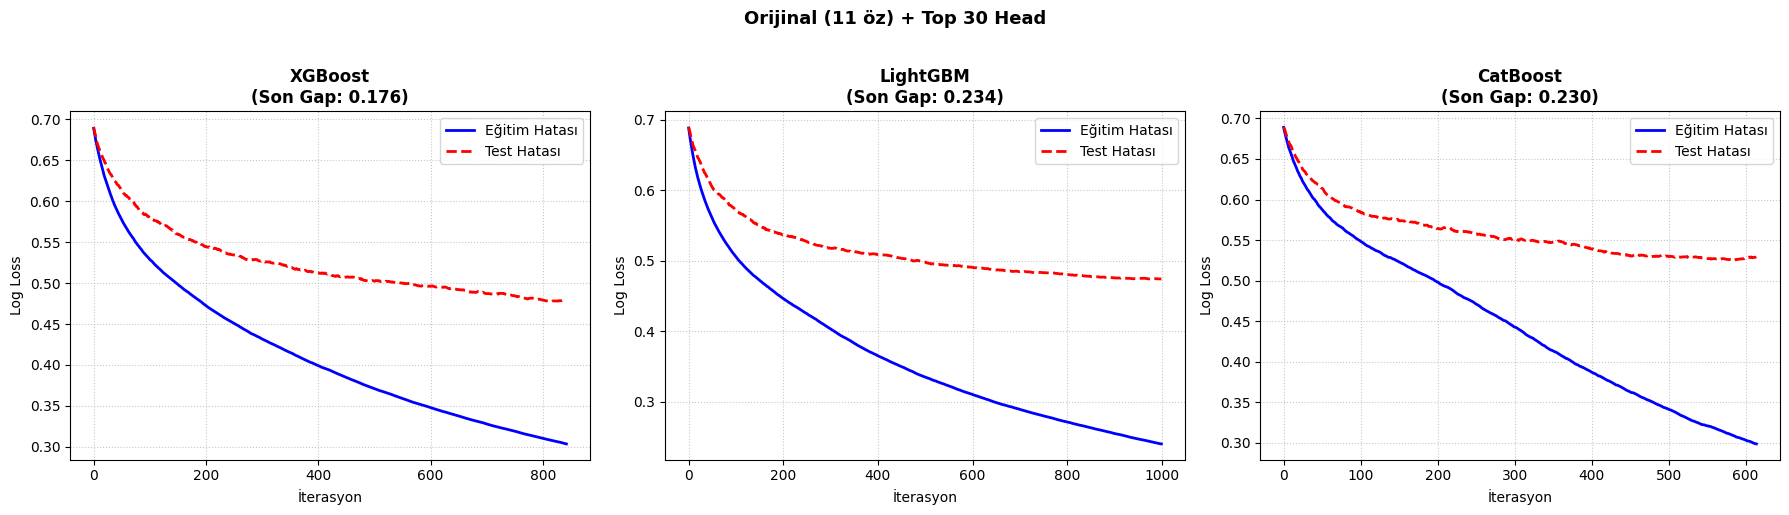


▶ XGBoost
              precision    recall  f1-score   support

      Yanlış       0.81      0.86      0.83        50
       Doğru       0.85      0.80      0.82        50

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100

  ROC-AUC  : 0.8748
  Log Loss : 0.4775

▶ LightGBM
              precision    recall  f1-score   support

      Yanlış       0.75      0.86      0.80        50
       Doğru       0.84      0.72      0.77        50

    accuracy                           0.79       100
   macro avg       0.80      0.79      0.79       100
weighted avg       0.80      0.79      0.79       100

  ROC-AUC  : 0.8720
  Log Loss : 0.4740

▶ CatBoost
              precision    recall  f1-score   support

      Yanlış       0.76      0.82      0.79        50
       Doğru       0.80      0.74      0.77        50

    accuracy                           0.78       100
   macro avg 

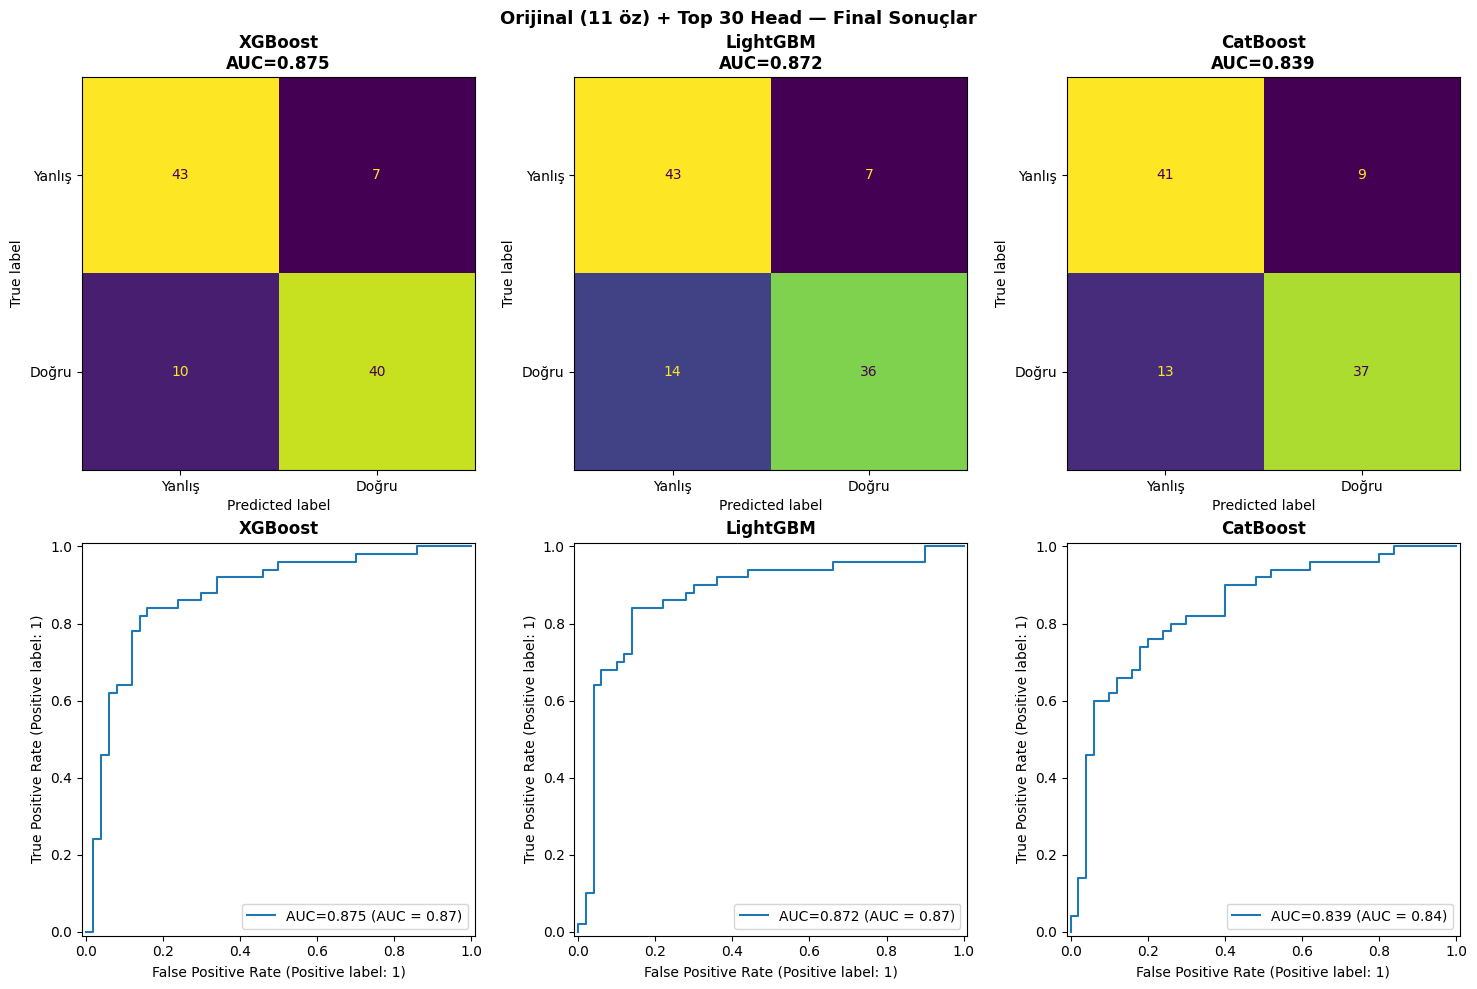

In [8]:
import numpy as np
import os
import pandas as pd
from sklearn.metrics import roc_auc_score, classification_report, log_loss
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Her head için kaç öznitelik olduğunu hesapla
# Toplam sütun sayısı / (42 katman × 16 head)
N_FEATURES_PER_HEAD = X_train_ori.shape[1] // (42 * 16)
print(f"Özellik per head: {N_FEATURES_PER_HEAD}")

# =============================================================
# ADIM 1: Her attention head'i tek tek test et
# Amaç: 672 head arasından hangilerinin sinyal taşıdığını bul
# =============================================================
results_per_head = []
print("\nHer head test ediliyor...")

for layer in range(42):       # 42 transformer katmanı
    for head in range(16):    # her katmanda 16 head

        # Bu head'e ait sütunların başlangıç ve bitiş indeksleri
        start = (layer * 16 + head) * N_FEATURES_PER_HEAD
        end   = start + N_FEATURES_PER_HEAD

        # Sadece bu head'in özniteliklerini al
        X_tr = X_train_ori[:, start:end]
        X_te = X_test_ori[:,  start:end]

        # Hızlı test için küçük bir XGB modeli eğit (n=200)
        # early_stopping_rounds=20: 20 iterasyon boyunca
        # validation loss iyileşmezse dur → overfitting engellenir
        m = XGBClassifier(
            n_estimators=200,
            max_depth=3,          # sığ ağaç → overfitting azaltır
            learning_rate=0.05,
            reg_alpha=2.0,        # L1: gereksiz özellikleri sıfırlar
            reg_lambda=5.0,       # L2: ağırlıkların patlamasını engeller
            min_child_weight=10,  # küçük yaprakları engeller
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            early_stopping_rounds=20
        )
        m.fit(X_tr, y_train_ori,
              eval_set=[(X_tr, y_train_ori), (X_te, y_test_ori)],
              verbose=False)

        # Bu head'in tek başına sağladığı AUC değeri
        auc = roc_auc_score(y_test_ori, m.predict_proba(X_te)[:, 1])
        results_per_head.append({
            'layer': layer, 'head': head, 'auc': auc,
            'start': start, 'end': end
        })

# Head'leri AUC'a göre büyükten küçüğe sırala
df_heads_ori = pd.DataFrame(results_per_head).sort_values('auc', ascending=False)
print("\n--- En İyi 10 Head (orijinal 11 özellik) ---")
print(df_heads_ori.head(10).to_string(index=False))

# =============================================================
# ADIM 2: En iyi N head kombinasyonunu bul
# Amaç: Kaç head birleştirilince en yüksek AUC elde edilir?
# =============================================================
print("\n--- En İyi N Head Kombinasyonu ---")
best_auc   = 0
best_top_n = 0

for top_n in [5, 10, 20, 30, 40, 50, 60, 80]:

    # AUC'a göre sıralanmış listeden ilk top_n head'i seç
    top_heads = df_heads_ori.head(top_n)

    # Seçilen head'lerin sütun indekslerini birleştir
    cols = []
    for _, row in top_heads.iterrows():
        cols.extend(range(int(row['start']), int(row['end'])))

    # Birleştirilmiş öznitelik uzayı
    X_tr = X_train_ori[:, cols]
    X_te = X_test_ori[:,  cols]

    # Adım 1'den biraz daha güçlü model (n=500)
    # subsample=0.6: her ağaçta verinin %60'ına bak → gürültü direnci
    # colsample_bytree=0.5: her ağaçta özniteliklerin %50'sine bak
    m = XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,   # daha yavaş öğren → daha iyi genelleme
        reg_alpha=3.0,        # L1 düzenlileştirme
        reg_lambda=8.0,       # L2 düzenlileştirme
        min_child_weight=15,
        subsample=0.6,
        colsample_bytree=0.5,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        early_stopping_rounds=30  # 30 iterasyon iyileşmezse dur
    )
    m.fit(X_tr, y_train_ori,
          eval_set=[(X_tr, y_train_ori), (X_te, y_test_ori)],
          verbose=False)

    auc = roc_auc_score(y_test_ori, m.predict_proba(X_te)[:, 1])
    print(f"Top {top_n:2d} head ({len(cols):4d} sütun) → AUC: {auc:.4f}")

    # En yüksek AUC veren top_n değerini kaydet
    if auc > best_auc:
        best_auc   = auc
        best_top_n = top_n

print(f"\nEn iyi: Top {best_top_n} head → AUC: {best_auc:.4f}")

# =============================================================
# ADIM 3: En iyi kombinasyonla üç modeli tam eğit
# Amaç: XGBoost, LightGBM ve CatBoost karşılaştırmalı değerlendir
# =============================================================
print(f"\n--- Top {best_top_n} Head ile Tam Eğitim ---")

# Adım 2'de bulunan en iyi head'lerin sütunlarını al
top_heads = df_heads_ori.head(best_top_n)
cols = []
for _, row in top_heads.iterrows():
    cols.extend(range(int(row['start']), int(row['end'])))

X_tr = X_train_ori[:, cols]
X_te = X_test_ori[:,  cols]

# XGBoost: n=1000, tam eğitim
# Adım 2'ye göre daha fazla iterasyon → daha iyi yakınsama
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.5,
    reg_alpha=3.0,         # L1: gereksiz attention özelliklerini sıfırlar
    reg_lambda=8.0,        # L2: ağırlıkların patlamasını engeller
    min_child_weight=15,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
    early_stopping_rounds=30
)

# LightGBM: num_leaves=7 → max_depth=3 ile uyumlu (2^3=8, 7 güvenli)
# class_weight='balanced': dengeli sınıf ağırlıkları
lgb_model = LGBMClassifier(
    n_estimators=1000,
    max_depth=3,
    num_leaves=7,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.5,
    reg_alpha=3.0,
    reg_lambda=8.0,
    min_child_weight=15,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

# CatBoost: l2_leaf_reg=8.0 → yaprak değerlerini küçültür
# auto_class_weights='Balanced': sınıf dengesini otomatik ayarlar
cat_model = CatBoostClassifier(
    iterations=1000,
    depth=3,
    learning_rate=0.03,
    l2_leaf_reg=8.0,
    auto_class_weights='Balanced',
    early_stopping_rounds=30,
    random_seed=SEED,
    verbose=0
)

# Modelleri eğit
# eval_set: hem eğitim hem test seti izlenir
# → öğrenme eğrisi çizmek ve early stopping için
xgb_model.fit(X_tr, y_train_ori,
              eval_set=[(X_tr, y_train_ori), (X_te, y_test_ori)],
              verbose=False)

# LightGBM'de early stopping fit() içinde verilir
lgb_model.fit(X_tr, y_train_ori,
              eval_set=[(X_tr, y_train_ori), (X_te, y_test_ori)],
              eval_names=['Train', 'Test'],
              eval_metric='binary_logloss',
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(-1)])

cat_model.fit(X_tr, y_train_ori,
              eval_set=(X_te, y_test_ori),
              verbose=False)

# =============================================================
# ADIM 4: Öğrenme eğrilerini çiz
# Amaç: Eğitim ve test loss'un iterasyonla nasıl değiştiğini göster
# Gap küçükse: overfitting yok ✅
# Gap büyükse: model eğitim setini ezberlemiş ❌
# =============================================================
xgb_res = xgb_model.evals_result()
lgb_res  = lgb_model.evals_result_
cat_res  = cat_model.get_evals_result()
metric   = list(lgb_res['Train'].keys())[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tr, te, title in zip(
    axes,
    [xgb_res['validation_0']['logloss'],
     lgb_res['Train'][metric],
     cat_res['learn']['Logloss']],
    [xgb_res['validation_1']['logloss'],
     lgb_res['Test'][metric],
     cat_res['validation']['Logloss']],
    ['XGBoost', 'LightGBM', 'CatBoost']
):
    ax.plot(tr, label='Eğitim Hatası', color='blue', linewidth=2)
    ax.plot(te, label='Test Hatası',   color='red',  linewidth=2, linestyle='--')
    gap = te[-1] - tr[-1]
    ax.set_title(f'{title}\n(Son Gap: {gap:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('İterasyon')
    ax.set_ylabel('Log Loss')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

plt.suptitle(f'Orijinal (11 öz) + Top {best_top_n} Head',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =============================================================
# ADIM 5: Performans metriklerini hesapla ve raporla
# Accuracy, Precision, Recall, F1, ROC-AUC, Log-Loss
# =============================================================
print("=" * 60)
results_ori = {}
for name, clf in [('XGBoost', xgb_model),
                   ('LightGBM', lgb_model),
                   ('CatBoost', cat_model)]:

    y_pred  = clf.predict(X_te)           # sınıf tahmini (0/1)
    y_proba = clf.predict_proba(X_te)[:, 1]  # pozitif sınıf olasılığı
    auc     = roc_auc_score(y_test_ori, y_proba)
    ll      = log_loss(y_test_ori, y_proba)

    print(f"\n▶ {name}")
    # Yanlış ve Doğru sınıfları için ayrı ayrı metrikler
    print(classification_report(y_test_ori, y_pred,
                                target_names=["Yanlış", "Doğru"]))
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Log Loss : {ll:.4f}")

    # Sonuçları ileriki görselleştirme için kaydet
    results_ori[name] = {
        "clf": clf, "y_pred": y_pred,
        "y_proba": y_proba, "auc": auc, "log_loss": ll
    }
print("=" * 60)

# =============================================================
# ADIM 6: Confusion Matrix ve ROC Curve görselleştir
# Confusion Matrix: hangi sınıflar karıştırılıyor?
# ROC Curve: farklı eşik değerlerinde TPR vs FPR dengesi
# =============================================================
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for col, (name, res) in enumerate(results_ori.items()):

    # Üst satır: Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test_ori, res["y_pred"],
        display_labels=["Yanlış", "Doğru"],
        ax=axes[0][col], colorbar=False
    )
    axes[0][col].set_title(f'{name}\nAUC={res["auc"]:.3f}',
                            fontweight='bold')

    # Alt satır: ROC Curve
    RocCurveDisplay.from_predictions(
        y_test_ori, res["y_proba"],
        name=f"AUC={res['auc']:.3f}",
        ax=axes[1][col]
    )
    axes[1][col].set_title(name, fontweight='bold')

plt.suptitle(f"Orijinal (11 öz) + Top {best_top_n} Head — Final Sonuçlar",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2) 19 özellik için (v1)

In [35]:
FEAT_DIR = os.path.join(KAYIT_DIR, "features_ex_2_v1")

# Dosyaları yükle
X_train = np.load(os.path.join(FEAT_DIR, "train_X.npy"))
y_train = np.load(os.path.join(FEAT_DIR, "train_y.npy"))
X_test  = np.load(os.path.join(FEAT_DIR, "test_X.npy"))
y_test  = np.load(os.path.join(FEAT_DIR, "test_y.npy"))

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (1000, 12768)
y_train: (1000,)
X_test:  (100, 12768)
y_test:  (100,)


In [36]:
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import numpy as np

# v1 verisi yüklü (12768 sütun)
# Her katman-head kombinasyonunu ayrı ayrı test et

N_FEATURES_PER_HEAD = 19  # her head için 19 özellik
results_per_head = []

print("Her katman-head kombinasyonu test ediliyor...")
for layer in range(42):
    for head in range(16):
        start = (layer * 16 + head) * N_FEATURES_PER_HEAD
        end   = start + N_FEATURES_PER_HEAD

        X_tr = X_train[:, start:end]
        X_te = X_test[:,  start:end]

        m = XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            reg_alpha=2.0, reg_lambda=5.0, min_child_weight=10,
            eval_metric='logloss', random_state=42,
            n_jobs=-1, verbosity=0, early_stopping_rounds=20
        )
        m.fit(X_tr, y_train,
              eval_set=[(X_tr, y_train), (X_te, y_test)],
              verbose=False)

        auc = roc_auc_score(y_test, m.predict_proba(X_te)[:, 1])
        results_per_head.append({
            'layer': layer, 'head': head, 'auc': auc,
            'start': start, 'end': end
        })

import pandas as pd
df_heads = pd.DataFrame(results_per_head).sort_values('auc', ascending=False)

print("\n--- En İyi 20 Layer-Head Kombinasyonu ---")
print(df_heads.head(20).to_string(index=False))

print(f"\nEn iyi tek head AUC: {df_heads.iloc[0]['auc']:.4f}")
print(f"Layer: {df_heads.iloc[0]['layer']}, Head: {df_heads.iloc[0]['head']}")

Her katman-head kombinasyonu test ediliyor...

--- En İyi 20 Layer-Head Kombinasyonu ---
 layer  head    auc  start   end
    23     4 0.6636   7068  7087
    29     9 0.6484   8987  9006
    21     6 0.6444   6498  6517
    12     0 0.6440   3648  3667
    27     4 0.6364   8284  8303
    15     9 0.6328   4731  4750
    18     0 0.6300   5472  5491
    27     7 0.6298   8341  8360
    39     3 0.6270  11913 11932
    22     6 0.6252   6802  6821
    26    10 0.6192   8094  8113
     5     8 0.6192   1672  1691
    37    13 0.6188  11495 11514
    23    10 0.6172   7182  7201
     8    11 0.6158   2641  2660
    36    15 0.6136  11229 11248
    21    15 0.6132   6669  6688
    23     8 0.6130   7144  7163
    18    10 0.6124   5662  5681
    28     0 0.6122   8512  8531

En iyi tek head AUC: 0.6636
Layer: 23.0, Head: 4.0


In [37]:
# Top 30 head'in feature importance'ına bak
import numpy as np
import pandas as pd

feature_names_per_head = [
    'mean', 'max', 'std', 'entropy', 'bos', 'top5', 'com',
    'skew', 'kurt', 'gini', 'uniform',
    'long_range', 'local_attn', 'long_local_ratio',
    'symmetry', 'dominant_count', 'full_entropy', 'col_std', 'row_max_mean'
]

# Top 30 head sütunlarını yeniden oluştur
top30 = df_heads.head(30)
cols = []
col_names = []
for _, row in top30.iterrows():
    start = int(row['start'])
    layer = int(row['layer'])
    head  = int(row['head'])
    for i, fname in enumerate(feature_names_per_head):
        cols.append(start + i)
        col_names.append(f"L{layer}_H{head}_{fname}")

X_tr = X_train[:, cols]
X_te = X_test[:,  cols]

# XGB importance
from xgboost import XGBClassifier
m = XGBClassifier(
    n_estimators=500, max_depth=3, learning_rate=0.03,
    reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
    subsample=0.6, colsample_bytree=0.5,
    eval_metric='logloss', random_state=42,
    n_jobs=-1, verbosity=0, early_stopping_rounds=30
)
m.fit(X_tr, y_train,
      eval_set=[(X_tr, y_train), (X_te, y_test)],
      verbose=False)

imp_df = pd.DataFrame({
    'Feature': col_names,
    'Importance': m.feature_importances_
}).sort_values('Importance', ascending=False)

# Özellik tipi bazlı özet
imp_df['feat_type'] = imp_df['Feature'].apply(lambda x: x.split('_')[-1])
print("Özellik tipi bazlı ortalama önem:")
print(imp_df.groupby('feat_type')['Importance'].mean().sort_values(ascending=False))

print("\nEn önemli 20 özellik:")
print(imp_df.head(20).to_string(index=False))

Özellik tipi bazlı ortalama önem:
feat_type
uniform     0.002729
bos         0.002547
gini        0.002546
com         0.002517
top5        0.002479
attn        0.002417
max         0.002349
skew        0.002221
std         0.002203
entropy     0.001968
kurt        0.001828
mean        0.001223
count       0.000738
symmetry    0.000173
ratio       0.000000
range       0.000000
Name: Importance, dtype: float32

En önemli 20 özellik:
               Feature  Importance feat_type
           L18_H10_bos    0.007072       bos
        L27_H7_uniform    0.006800   uniform
       L18_H10_uniform    0.006552   uniform
        L27_H7_entropy    0.006427   entropy
   L33_H2_full_entropy    0.006212   entropy
           L18_H10_com    0.006174       com
           L13_H8_skew    0.006063      skew
           L18_H10_std    0.006003       std
            L27_H7_com    0.005695       com
L19_H14_dominant_count    0.005478     count
           L23_H8_skew    0.005209      skew
        L12_H0_col_std  

In [38]:
# En iyi N head'i seç ve birleştir
for top_n in [5, 10, 20, 30]:
    top_heads = df_heads.head(top_n)

    # Seçilen head'lerin sütunlarını birleştir
    cols = []
    for _, row in top_heads.iterrows():
        cols.extend(range(int(row['start']), int(row['end'])))

    X_tr = X_train[:, cols]
    X_te = X_test[:,  cols]

    m = XGBClassifier(
        n_estimators=500, max_depth=3, learning_rate=0.03,
        reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
        subsample=0.6, colsample_bytree=0.5,
        eval_metric='logloss', random_state=42,
        n_jobs=-1, verbosity=0, early_stopping_rounds=30
    )
    m.fit(X_tr, y_train,
          eval_set=[(X_tr, y_train), (X_te, y_test)],
          verbose=False)

    auc = roc_auc_score(y_test, m.predict_proba(X_te)[:, 1])
    print(f"Top {top_n:2d} head → AUC: {auc:.4f} | Sütun: {len(cols)}")

Top  5 head → AUC: 0.6316 | Sütun: 95
Top 10 head → AUC: 0.7284 | Sütun: 190
Top 20 head → AUC: 0.7396 | Sütun: 380
Top 30 head → AUC: 0.7632 | Sütun: 570


In [39]:
for top_n in [40, 50, 60, 80, 100, 150, 200]:
    top_heads = df_heads.head(top_n)

    cols = []
    for _, row in top_heads.iterrows():
        cols.extend(range(int(row['start']), int(row['end'])))

    X_tr = X_train[:, cols]
    X_te = X_test[:,  cols]

    m = XGBClassifier(
        n_estimators=500, max_depth=3, learning_rate=0.03,
        reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
        subsample=0.6, colsample_bytree=0.5,
        eval_metric='logloss', random_state=42,
        n_jobs=-1, verbosity=0, early_stopping_rounds=30
    )
    m.fit(X_tr, y_train,
          eval_set=[(X_tr, y_train), (X_te, y_test)],
          verbose=False)

    auc = roc_auc_score(y_test, m.predict_proba(X_te)[:, 1])
    print(f"Top {top_n:3d} head ({len(cols):4d} sütun) → AUC: {auc:.4f}")

Top  40 head ( 760 sütun) → AUC: 0.7552
Top  50 head ( 950 sütun) → AUC: 0.7532
Top  60 head (1140 sütun) → AUC: 0.7420
Top  80 head (1520 sütun) → AUC: 0.7528
Top 100 head (1900 sütun) → AUC: 0.7204
Top 150 head (2850 sütun) → AUC: 0.6744
Top 200 head (3800 sütun) → AUC: 0.6940


Özellik per head: 19

Her head test ediliyor...

--- En İyi 10 Head (v1, 19 özellik) ---
 layer  head    auc  start   end
    23     4 0.6636   7068  7087
    29     9 0.6484   8987  9006
    21     6 0.6444   6498  6517
    12     0 0.6440   3648  3667
    27     4 0.6364   8284  8303
    15     9 0.6328   4731  4750
    18     0 0.6300   5472  5491
    27     7 0.6298   8341  8360
    39     3 0.6270  11913 11932
    22     6 0.6252   6802  6821

--- En İyi N Head Kombinasyonu ---
Top  5 head (  95 sütun) → AUC: 0.6316
Top 10 head ( 190 sütun) → AUC: 0.7284
Top 20 head ( 380 sütun) → AUC: 0.7396
Top 30 head ( 570 sütun) → AUC: 0.7632
Top 40 head ( 760 sütun) → AUC: 0.7552
Top 50 head ( 950 sütun) → AUC: 0.7532
Top 60 head (1140 sütun) → AUC: 0.7420
Top 80 head (1520 sütun) → AUC: 0.7528

En iyi: Top 30 head → AUC: 0.7632

--- Top 30 Head ile Tam Eğitim ---


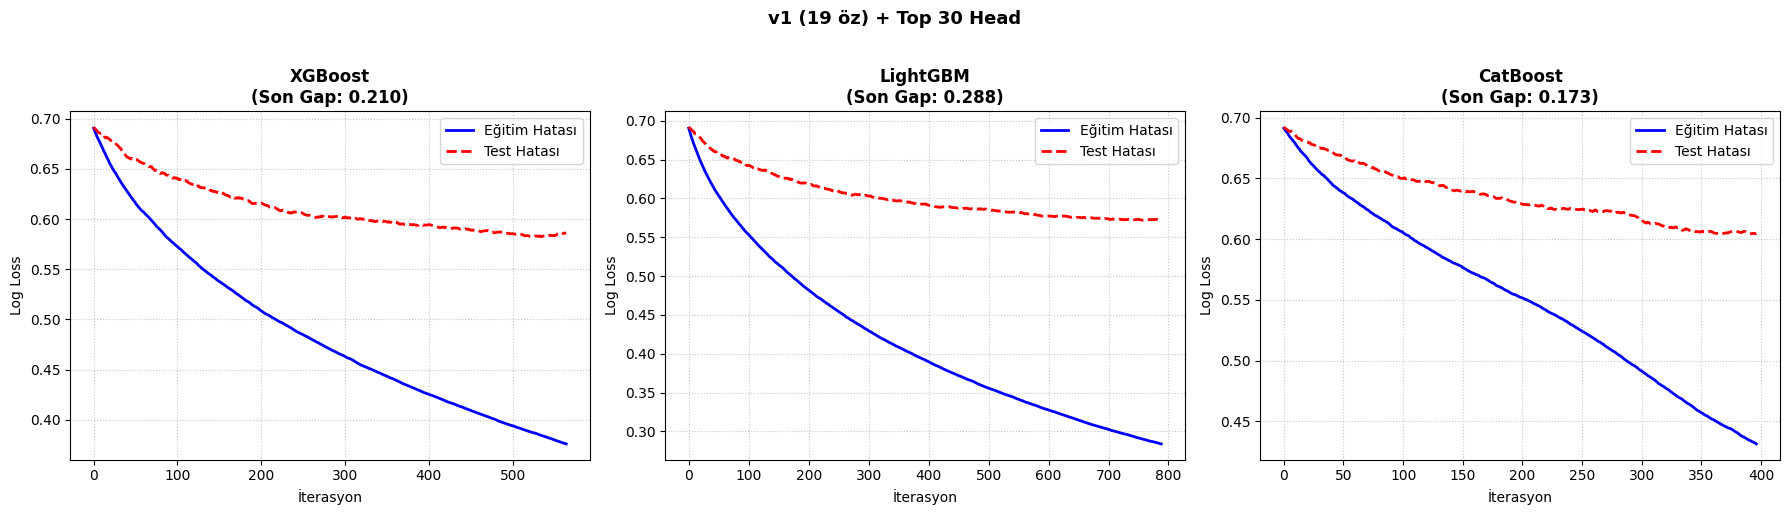


▶ XGBoost
              precision    recall  f1-score   support

      Yanlış       0.73      0.74      0.73        50
       Doğru       0.73      0.72      0.73        50

    accuracy                           0.73       100
   macro avg       0.73      0.73      0.73       100
weighted avg       0.73      0.73      0.73       100

  ROC-AUC  : 0.7632
  Log Loss : 0.5824

▶ LightGBM
              precision    recall  f1-score   support

      Yanlış       0.73      0.74      0.73        50
       Doğru       0.73      0.72      0.73        50

    accuracy                           0.73       100
   macro avg       0.73      0.73      0.73       100
weighted avg       0.73      0.73      0.73       100

  ROC-AUC  : 0.7708
  Log Loss : 0.5720

▶ CatBoost
              precision    recall  f1-score   support

      Yanlış       0.71      0.70      0.71        50
       Doğru       0.71      0.72      0.71        50

    accuracy                           0.71       100
   macro avg 

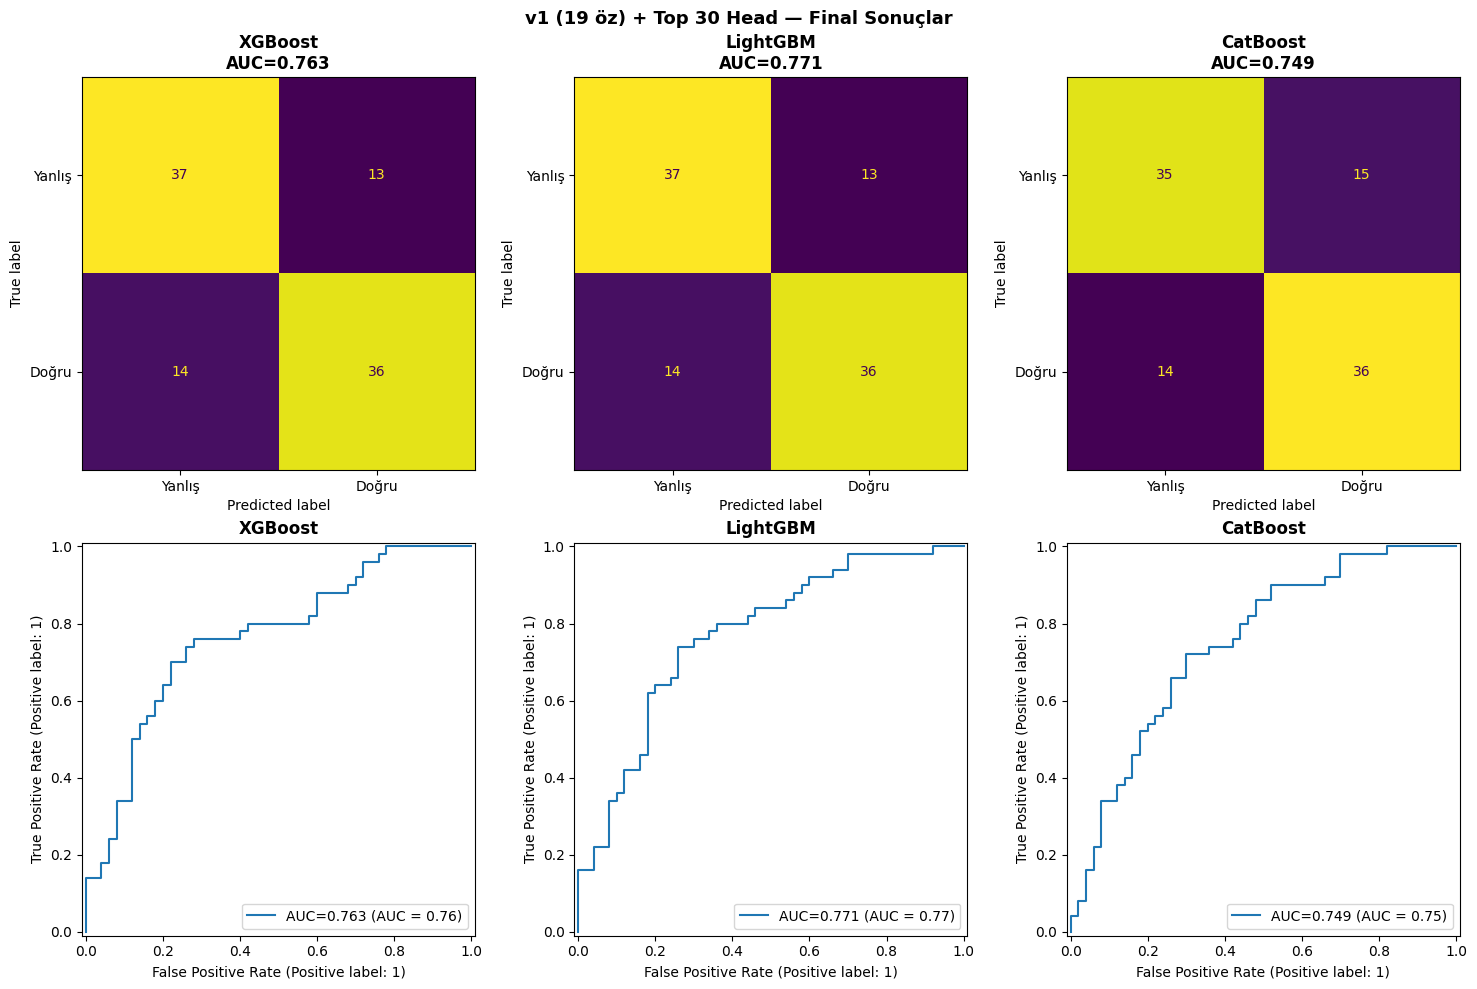

In [40]:
N_FEATURES_PER_HEAD = X_train.shape[1] // (42 * 16)
print(f"Özellik per head: {N_FEATURES_PER_HEAD}")  # 19 olmalı

# --- 1. HER HEAD'İ AYRI AYRI TEST ET ---
results_per_head = []
print("\nHer head test ediliyor...")

for layer in range(42):
    for head in range(16):
        start = (layer * 16 + head) * N_FEATURES_PER_HEAD
        end   = start + N_FEATURES_PER_HEAD

        X_tr = X_train[:, start:end]
        X_te = X_test[:,  start:end]

        m = XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            reg_alpha=2.0, reg_lambda=5.0, min_child_weight=10,
            eval_metric='logloss', random_state=42,
            n_jobs=-1, verbosity=0, early_stopping_rounds=20
        )
        m.fit(X_tr, y_train,
              eval_set=[(X_tr, y_train), (X_te, y_test)],
              verbose=False)

        auc = roc_auc_score(y_test, m.predict_proba(X_te)[:, 1])
        results_per_head.append({
            'layer': layer, 'head': head, 'auc': auc,
            'start': start, 'end': end
        })

df_heads_v1 = pd.DataFrame(results_per_head).sort_values('auc', ascending=False)
print("\n--- En İyi 10 Head (v1, 19 özellik) ---")
print(df_heads_v1.head(10).to_string(index=False))

# --- 2. EN İYİ N HEAD KOMBİNASYONU ---
print("\n--- En İyi N Head Kombinasyonu ---")
best_auc   = 0
best_top_n = 0

for top_n in [5, 10, 20, 30, 40, 50, 60, 80]:
    top_heads = df_heads_v1.head(top_n)
    cols = []
    for _, row in top_heads.iterrows():
        cols.extend(range(int(row['start']), int(row['end'])))

    X_tr = X_train[:, cols]
    X_te = X_test[:,  cols]

    m = XGBClassifier(
        n_estimators=500, max_depth=3, learning_rate=0.03,
        reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
        subsample=0.6, colsample_bytree=0.5,
        eval_metric='logloss', random_state=42,
        n_jobs=-1, verbosity=0, early_stopping_rounds=30
    )
    m.fit(X_tr, y_train,
          eval_set=[(X_tr, y_train), (X_te, y_test)],
          verbose=False)

    auc = roc_auc_score(y_test, m.predict_proba(X_te)[:, 1])
    print(f"Top {top_n:2d} head ({len(cols):4d} sütun) → AUC: {auc:.4f}")

    if auc > best_auc:
        best_auc   = auc
        best_top_n = top_n

print(f"\nEn iyi: Top {best_top_n} head → AUC: {best_auc:.4f}")

# --- 3. EN İYİ KOMBİNASYONLA TAM EĞİTİM ---
print(f"\n--- Top {best_top_n} Head ile Tam Eğitim ---")

top_heads = df_heads_v1.head(best_top_n)
cols = []
for _, row in top_heads.iterrows():
    cols.extend(range(int(row['start']), int(row['end'])))

X_tr = X_train[:, cols]
X_te = X_test[:,  cols]

xgb_model = XGBClassifier(
    n_estimators=1000, max_depth=3, learning_rate=0.03,
    subsample=0.6, colsample_bytree=0.5,
    reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
    eval_metric='logloss', random_state=SEED,
    n_jobs=-1, verbosity=0, early_stopping_rounds=30
)

lgb_model = LGBMClassifier(
    n_estimators=1000, max_depth=3, num_leaves=7, learning_rate=0.03,
    subsample=0.6, colsample_bytree=0.5,
    reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)

cat_model = CatBoostClassifier(
    iterations=1000, depth=3, learning_rate=0.03,
    l2_leaf_reg=8.0, auto_class_weights='Balanced',
    early_stopping_rounds=30, random_seed=SEED, verbose=0
)

xgb_model.fit(X_tr, y_train,
              eval_set=[(X_tr, y_train), (X_te, y_test)],
              verbose=False)

lgb_model.fit(X_tr, y_train,
              eval_set=[(X_tr, y_train), (X_te, y_test)],
              eval_names=['Train', 'Test'], eval_metric='binary_logloss',
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

cat_model.fit(X_tr, y_train,
              eval_set=(X_te, y_test), verbose=False)

# --- 4. GRAFİK ---
xgb_res = xgb_model.evals_result()
lgb_res  = lgb_model.evals_result_
cat_res  = cat_model.get_evals_result()
metric   = list(lgb_res['Train'].keys())[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tr, te, title in zip(
    axes,
    [xgb_res['validation_0']['logloss'],
     lgb_res['Train'][metric],
     cat_res['learn']['Logloss']],
    [xgb_res['validation_1']['logloss'],
     lgb_res['Test'][metric],
     cat_res['validation']['Logloss']],
    ['XGBoost', 'LightGBM', 'CatBoost']
):
    ax.plot(tr, label='Eğitim Hatası', color='blue', linewidth=2)
    ax.plot(te, label='Test Hatası',   color='red',  linewidth=2, linestyle='--')
    gap = te[-1] - tr[-1]
    ax.set_title(f'{title}\n(Son Gap: {gap:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('İterasyon')
    ax.set_ylabel('Log Loss')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

plt.suptitle(f'v1 (19 öz) + Top {best_top_n} Head',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- 5. SONUÇLAR ---
print("=" * 60)
results_v1 = {}
for name, clf in [('XGBoost', xgb_model), ('LightGBM', lgb_model), ('CatBoost', cat_model)]:
    y_pred  = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    ll      = log_loss(y_test, y_proba)

    print(f"\n▶ {name}")
    print(classification_report(y_test, y_pred, target_names=["Yanlış", "Doğru"]))
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Log Loss : {ll:.4f}")

    results_v1[name] = {
        "clf": clf, "y_pred": y_pred,
        "y_proba": y_proba, "auc": auc, "log_loss": ll
    }
print("=" * 60)

# --- 6. CONFUSION MATRIX + ROC CURVE ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for col, (name, res) in enumerate(results_v1.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res["y_pred"],
        display_labels=["Yanlış", "Doğru"],
        ax=axes[0][col], colorbar=False
    )
    axes[0][col].set_title(f'{name}\nAUC={res["auc"]:.3f}', fontweight='bold')

    RocCurveDisplay.from_predictions(
        y_test, res["y_proba"],
        name=f"AUC={res['auc']:.3f}",
        ax=axes[1][col]
    )
    axes[1][col].set_title(name, fontweight='bold')

plt.suptitle(f"v1 (19 öz) + Top {best_top_n} Head — Final Sonuçlar",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3) 22 Özellik için (v1_plus)

In [41]:
FEAT_DIR_V2 = os.path.join(KAYIT_DIR, "features_ex_2_v1_plus")
X_train_v2 = np.load(os.path.join(FEAT_DIR_V2, "train_X.npy"))
y_train_v2 = np.load(os.path.join(FEAT_DIR_V2, "train_y.npy"))
X_test_v2  = np.load(os.path.join(FEAT_DIR_V2, "test_X.npy"))
y_test_v2  = np.load(os.path.join(FEAT_DIR_V2, "test_y.npy"))

print(f"X_train_v2: {X_train_v2.shape}")  # (1000, 14784)
print(f"X_test_v2:  {X_test_v2.shape}")   # (100, 14784)

X_train_v2: (1000, 14784)
X_test_v2:  (100, 14784)


In [42]:
# --- 1. Her head'i ayrı ayrı test et ---
N_FEATURES_PER_HEAD = 22  # v1_plus: 22 özellik per head
results_per_head = []

print("Her head test ediliyor...")
for layer in range(42):
    for head in range(16):
        start = (layer * 16 + head) * N_FEATURES_PER_HEAD
        end   = start + N_FEATURES_PER_HEAD

        X_tr = X_train_v2[:, start:end]
        X_te = X_test_v2[:,  start:end]

        m = XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            reg_alpha=2.0, reg_lambda=5.0, min_child_weight=10,
            eval_metric='logloss', random_state=42,
            n_jobs=-1, verbosity=0, early_stopping_rounds=20
        )
        m.fit(X_tr, y_train_v2,
              eval_set=[(X_tr, y_train_v2), (X_te, y_test_v2)],
              verbose=False)

        auc = roc_auc_score(y_test_v2, m.predict_proba(X_te)[:, 1])
        results_per_head.append({
            'layer': layer, 'head': head, 'auc': auc,
            'start': start, 'end': end
        })

df_heads_plus = pd.DataFrame(results_per_head).sort_values('auc', ascending=False)
print("\n--- En İyi 10 Head (v1_plus) ---")
print(df_heads_plus.head(10).to_string(index=False))

# --- 2. En iyi N head kombinasyonu ---
print("\n--- En İyi N Head Kombinasyonu ---")
for top_n in [5, 10, 20, 30, 40, 50]:
    top_heads = df_heads_plus.head(top_n)
    cols = []
    for _, row in top_heads.iterrows():
        cols.extend(range(int(row['start']), int(row['end'])))

    X_tr = X_train_v2[:, cols]
    X_te = X_test_v2[:,  cols]

    m = XGBClassifier(
        n_estimators=500, max_depth=3, learning_rate=0.03,
        reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
        subsample=0.6, colsample_bytree=0.5,
        eval_metric='logloss', random_state=42,
        n_jobs=-1, verbosity=0, early_stopping_rounds=30
    )
    m.fit(X_tr, y_train_v2,
          eval_set=[(X_tr, y_train_v2), (X_te, y_test_v2)],
          verbose=False)

    auc = roc_auc_score(y_test_v2, m.predict_proba(X_te)[:, 1])
    print(f"Top {top_n:2d} head ({len(cols):4d} sütun) → AUC: {auc:.4f}")

Her head test ediliyor...

--- En İyi 10 Head (v1_plus) ---
 layer  head    auc  start   end
    16     9 0.6576   5830  5852
    12     0 0.6572   4224  4246
    18     0 0.6524   6336  6358
    19    11 0.6496   6930  6952
    41     3 0.6476  14498 14520
    19     7 0.6460   6842  6864
    15     9 0.6460   5478  5500
    21    12 0.6440   7656  7678
    15     2 0.6424   5324  5346
    10     8 0.6420   3696  3718

--- En İyi N Head Kombinasyonu ---
Top  5 head ( 110 sütun) → AUC: 0.7248
Top 10 head ( 220 sütun) → AUC: 0.7560
Top 20 head ( 440 sütun) → AUC: 0.7468
Top 30 head ( 660 sütun) → AUC: 0.7352
Top 40 head ( 880 sütun) → AUC: 0.7656
Top 50 head (1100 sütun) → AUC: 0.7652


Özellik per head: 22

Her head test ediliyor...

--- En İyi 10 Head (v1_plus, 22 özellik) ---
 layer  head    auc  start   end
    16     9 0.6576   5830  5852
    12     0 0.6572   4224  4246
    18     0 0.6524   6336  6358
    19    11 0.6496   6930  6952
    41     3 0.6476  14498 14520
    19     7 0.6460   6842  6864
    15     9 0.6460   5478  5500
    21    12 0.6440   7656  7678
    15     2 0.6424   5324  5346
    10     8 0.6420   3696  3718

--- En İyi N Head Kombinasyonu ---
Top  5 head ( 110 sütun) → AUC: 0.7248
Top 10 head ( 220 sütun) → AUC: 0.7560
Top 20 head ( 440 sütun) → AUC: 0.7468
Top 30 head ( 660 sütun) → AUC: 0.7352
Top 40 head ( 880 sütun) → AUC: 0.7656
Top 50 head (1100 sütun) → AUC: 0.7652
Top 60 head (1320 sütun) → AUC: 0.7468
Top 80 head (1760 sütun) → AUC: 0.7392

En iyi: Top 40 head → AUC: 0.7656

--- Top 40 Head ile Tam Eğitim ---


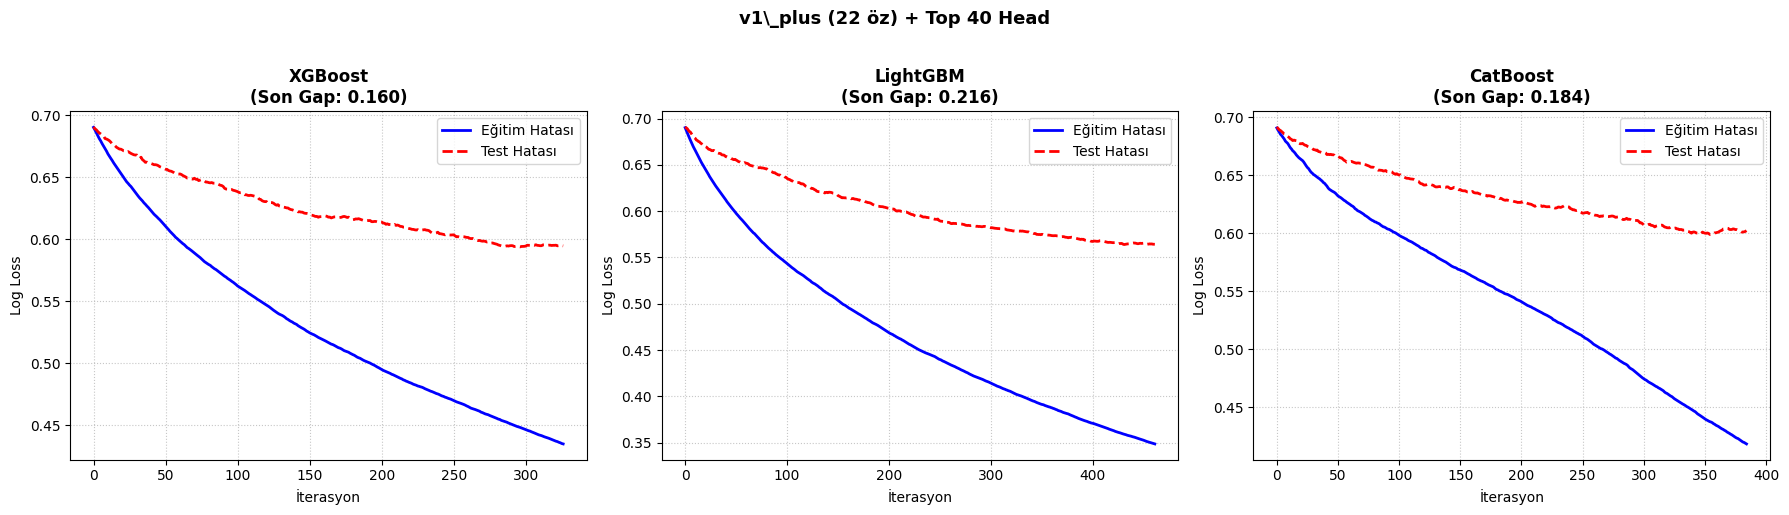


▶ XGBoost
              precision    recall  f1-score   support

      Yanlış       0.69      0.80      0.74        50
       Doğru       0.76      0.64      0.70        50

    accuracy                           0.72       100
   macro avg       0.73      0.72      0.72       100
weighted avg       0.73      0.72      0.72       100

  ROC-AUC  : 0.7656
  Log Loss : 0.5939

▶ LightGBM
              precision    recall  f1-score   support

      Yanlış       0.66      0.74      0.70        50
       Doğru       0.70      0.62      0.66        50

    accuracy                           0.68       100
   macro avg       0.68      0.68      0.68       100
weighted avg       0.68      0.68      0.68       100

  ROC-AUC  : 0.7840
  Log Loss : 0.5640

▶ CatBoost
              precision    recall  f1-score   support

      Yanlış       0.62      0.76      0.68        50
       Doğru       0.69      0.54      0.61        50

    accuracy                           0.65       100
   macro avg 

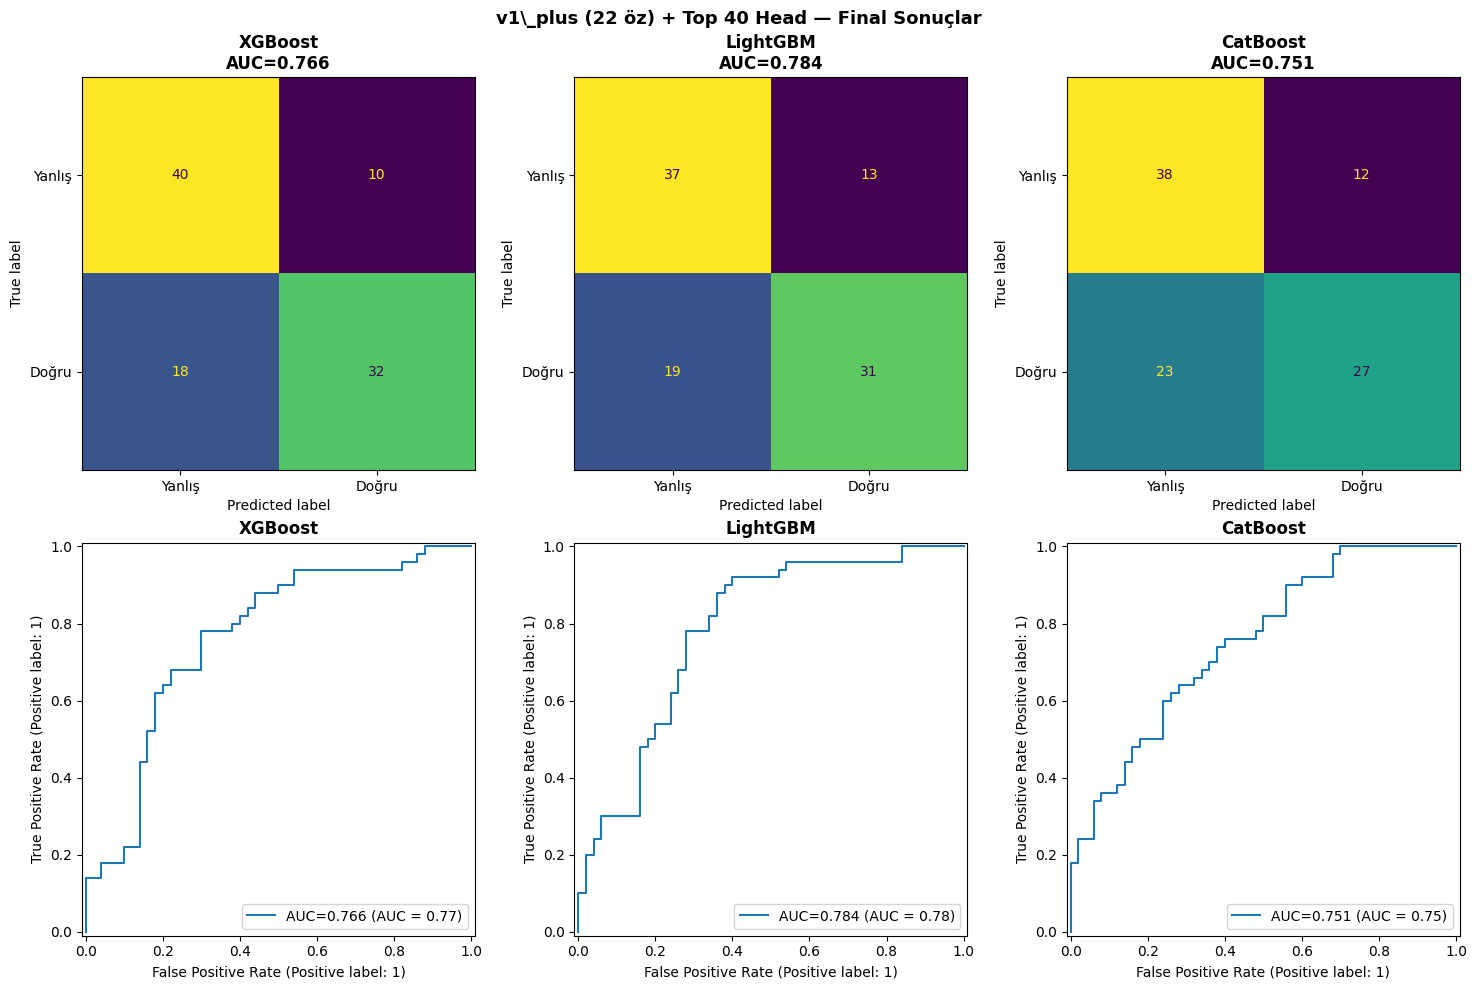

In [43]:
import numpy as np
import os
import pandas as pd
from sklearn.metrics import roc_auc_score, classification_report, log_loss, ConfusionMatrixDisplay, RocCurveDisplay
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

N_FEATURES_PER_HEAD = X_train_v2.shape[1] // (42 * 16)
print(f"Özellik per head: {N_FEATURES_PER_HEAD}")  # 22 olmalı

# --- 1. HER HEAD'İ AYRI AYRI TEST ET ---
results_per_head = []
print("\nHer head test ediliyor...")

for layer in range(42):
    for head in range(16):
        start = (layer * 16 + head) * N_FEATURES_PER_HEAD
        end   = start + N_FEATURES_PER_HEAD

        X_tr = X_train_v2[:, start:end]
        X_te = X_test_v2[:,  start:end]

        m = XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            reg_alpha=2.0, reg_lambda=5.0, min_child_weight=10,
            eval_metric='logloss', random_state=42,
            n_jobs=-1, verbosity=0, early_stopping_rounds=20
        )
        m.fit(X_tr, y_train_v2,
              eval_set=[(X_tr, y_train_v2), (X_te, y_test_v2)],
              verbose=False)

        auc = roc_auc_score(y_test_v2, m.predict_proba(X_te)[:, 1])
        results_per_head.append({
            'layer': layer, 'head': head, 'auc': auc,
            'start': start, 'end': end
        })

df_heads_v2 = pd.DataFrame(results_per_head).sort_values('auc', ascending=False)
print("\n--- En İyi 10 Head (v1_plus, 22 özellik) ---")
print(df_heads_v2.head(10).to_string(index=False))

# --- 2. EN İYİ N HEAD KOMBİNASYONU ---
print("\n--- En İyi N Head Kombinasyonu ---")
best_auc   = 0
best_top_n = 0

for top_n in [5, 10, 20, 30, 40, 50, 60, 80]:
    top_heads = df_heads_v2.head(top_n)
    cols = []
    for _, row in top_heads.iterrows():
        cols.extend(range(int(row['start']), int(row['end'])))

    X_tr = X_train_v2[:, cols]
    X_te = X_test_v2[:,  cols]

    m = XGBClassifier(
        n_estimators=500, max_depth=3, learning_rate=0.03,
        reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
        subsample=0.6, colsample_bytree=0.5,
        eval_metric='logloss', random_state=42,
        n_jobs=-1, verbosity=0, early_stopping_rounds=30
    )
    m.fit(X_tr, y_train_v2,
          eval_set=[(X_tr, y_train_v2), (X_te, y_test_v2)],
          verbose=False)

    auc = roc_auc_score(y_test_v2, m.predict_proba(X_te)[:, 1])
    print(f"Top {top_n:2d} head ({len(cols):4d} sütun) → AUC: {auc:.4f}")

    if auc > best_auc:
        best_auc   = auc
        best_top_n = top_n

print(f"\nEn iyi: Top {best_top_n} head → AUC: {best_auc:.4f}")

# --- 3. EN İYİ KOMBİNASYONLA TAM EĞİTİM ---
print(f"\n--- Top {best_top_n} Head ile Tam Eğitim ---")

top_heads = df_heads_v2.head(best_top_n)
cols = []
for _, row in top_heads.iterrows():
    cols.extend(range(int(row['start']), int(row['end'])))

X_tr = X_train_v2[:, cols]
X_te = X_test_v2[:,  cols]

xgb_model = XGBClassifier(
    n_estimators=1000, max_depth=3, learning_rate=0.03,
    subsample=0.6, colsample_bytree=0.5,
    reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
    eval_metric='logloss', random_state=SEED,
    n_jobs=-1, verbosity=0, early_stopping_rounds=30
)

lgb_model = LGBMClassifier(
    n_estimators=1000, max_depth=3, num_leaves=7, learning_rate=0.03,
    subsample=0.6, colsample_bytree=0.5,
    reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)

cat_model = CatBoostClassifier(
    iterations=1000, depth=3, learning_rate=0.03,
    l2_leaf_reg=8.0, auto_class_weights='Balanced',
    early_stopping_rounds=30, random_seed=SEED, verbose=0
)

xgb_model.fit(X_tr, y_train_v2,
              eval_set=[(X_tr, y_train_v2), (X_te, y_test_v2)],
              verbose=False)

lgb_model.fit(X_tr, y_train_v2,
              eval_set=[(X_tr, y_train_v2), (X_te, y_test_v2)],
              eval_names=['Train', 'Test'], eval_metric='binary_logloss',
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

cat_model.fit(X_tr, y_train_v2,
              eval_set=(X_te, y_test_v2), verbose=False)

# --- 4. GRAFİK ---
xgb_res = xgb_model.evals_result()
lgb_res  = lgb_model.evals_result_
cat_res  = cat_model.get_evals_result()
metric   = list(lgb_res['Train'].keys())[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tr, te, title in zip(
    axes,
    [xgb_res['validation_0']['logloss'],
     lgb_res['Train'][metric],
     cat_res['learn']['Logloss']],
    [xgb_res['validation_1']['logloss'],
     lgb_res['Test'][metric],
     cat_res['validation']['Logloss']],
    ['XGBoost', 'LightGBM', 'CatBoost']
):
    ax.plot(tr, label='Eğitim Hatası', color='blue', linewidth=2)
    ax.plot(te, label='Test Hatası',   color='red',  linewidth=2, linestyle='--')
    gap = te[-1] - tr[-1]
    ax.set_title(f'{title}\n(Son Gap: {gap:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('İterasyon')
    ax.set_ylabel('Log Loss')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

plt.suptitle(f'v1\_plus (22 öz) + Top {best_top_n} Head',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- 5. SONUÇLAR ---
print("=" * 60)
results_v1plus = {}
for name, clf in [('XGBoost', xgb_model), ('LightGBM', lgb_model), ('CatBoost', cat_model)]:
    y_pred  = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)[:, 1]
    auc     = roc_auc_score(y_test_v2, y_proba)
    ll      = log_loss(y_test_v2, y_proba)

    print(f"\n▶ {name}")
    print(classification_report(y_test_v2, y_pred, target_names=["Yanlış", "Doğru"]))
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Log Loss : {ll:.4f}")

    results_v1plus[name] = {
        "clf": clf, "y_pred": y_pred,
        "y_proba": y_proba, "auc": auc, "log_loss": ll
    }
print("=" * 60)

# --- 6. CONFUSION MATRIX + ROC CURVE ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for col, (name, res) in enumerate(results_v1plus.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_v2, res["y_pred"],
        display_labels=["Yanlış", "Doğru"],
        ax=axes[0][col], colorbar=False
    )
    axes[0][col].set_title(f'{name}\nAUC={res["auc"]:.3f}', fontweight='bold')

    RocCurveDisplay.from_predictions(
        y_test_v2, res["y_proba"],
        name=f"AUC={res['auc']:.3f}",
        ax=axes[1][col]
    )
    axes[1][col].set_title(name, fontweight='bold')

plt.suptitle(f"v1\_plus (22 öz) + Top {best_top_n} Head — Final Sonuçlar",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 4) 29 Özellik için (v1_plus2)

In [44]:
# --- 0. VERİYİ YÜKLE ---
FEAT_DIR_V1P2 = os.path.join(KAYIT_DIR, "features_ex_2_v1_plus2")
X_train_v1p2 = np.load(os.path.join(FEAT_DIR_V1P2, "train_X.npy"))
y_train_v1p2 = np.load(os.path.join(FEAT_DIR_V1P2, "train_y.npy"))
X_test_v1p2  = np.load(os.path.join(FEAT_DIR_V1P2, "test_X.npy"))
y_test_v1p2  = np.load(os.path.join(FEAT_DIR_V1P2, "test_y.npy"))

print(f"X_train: {X_train_v1p2.shape}")  # (1000, 18816)
print(f"X_test:  {X_test_v1p2.shape}")   # (100, 18816)

X_train: (1000, 18816)
X_test:  (100, 18816)


Özellik per head: 28

Her head test ediliyor...

--- En İyi 10 Head (v1_plus2) ---
 layer  head    auc  start   end
    18     0 0.6856   8064  8092
    21    15 0.6636   9828  9856
    19     7 0.6620   8708  8736
    19    11 0.6584   8820  8848
    22     6 0.6584  10024 10052
    21     3 0.6548   9492  9520
    23    14 0.6512  10696 10724
    22     4 0.6500   9968  9996
     5     8 0.6496   2464  2492
    35     3 0.6488  15764 15792

--- En İyi N Head Kombinasyonu ---
Top  5 head ( 140 sütun) → AUC: 0.7552
Top 10 head ( 280 sütun) → AUC: 0.8224
Top 20 head ( 560 sütun) → AUC: 0.7528
Top 30 head ( 840 sütun) → AUC: 0.7304
Top 40 head (1120 sütun) → AUC: 0.7296
Top 50 head (1400 sütun) → AUC: 0.6980
Top 60 head (1680 sütun) → AUC: 0.7260
Top 80 head (2240 sütun) → AUC: 0.7512

En iyi: Top 10 head → AUC: 0.8224

--- Top 10 Head ile Tam Eğitim ---


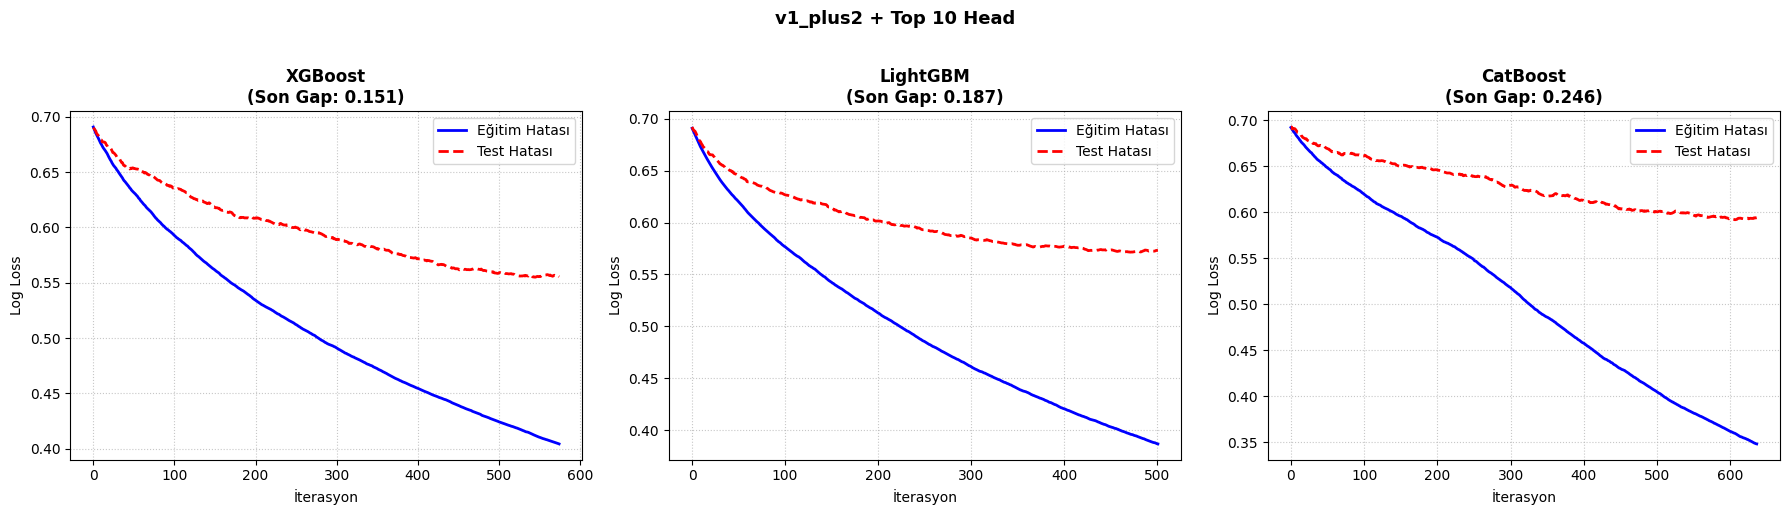


▶ XGBoost
              precision    recall  f1-score   support

      Yanlış       0.74      0.80      0.77        50
       Doğru       0.78      0.72      0.75        50

    accuracy                           0.76       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.76      0.76      0.76       100

  ROC-AUC  : 0.8152
  Log Loss : 0.5551

▶ LightGBM
              precision    recall  f1-score   support

      Yanlış       0.73      0.82      0.77        50
       Doğru       0.80      0.70      0.74        50

    accuracy                           0.76       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.76      0.76      0.76       100

  ROC-AUC  : 0.8068
  Log Loss : 0.5715

▶ CatBoost
              precision    recall  f1-score   support

      Yanlış       0.66      0.74      0.70        50
       Doğru       0.70      0.62      0.66        50

    accuracy                           0.68       100
   macro avg 

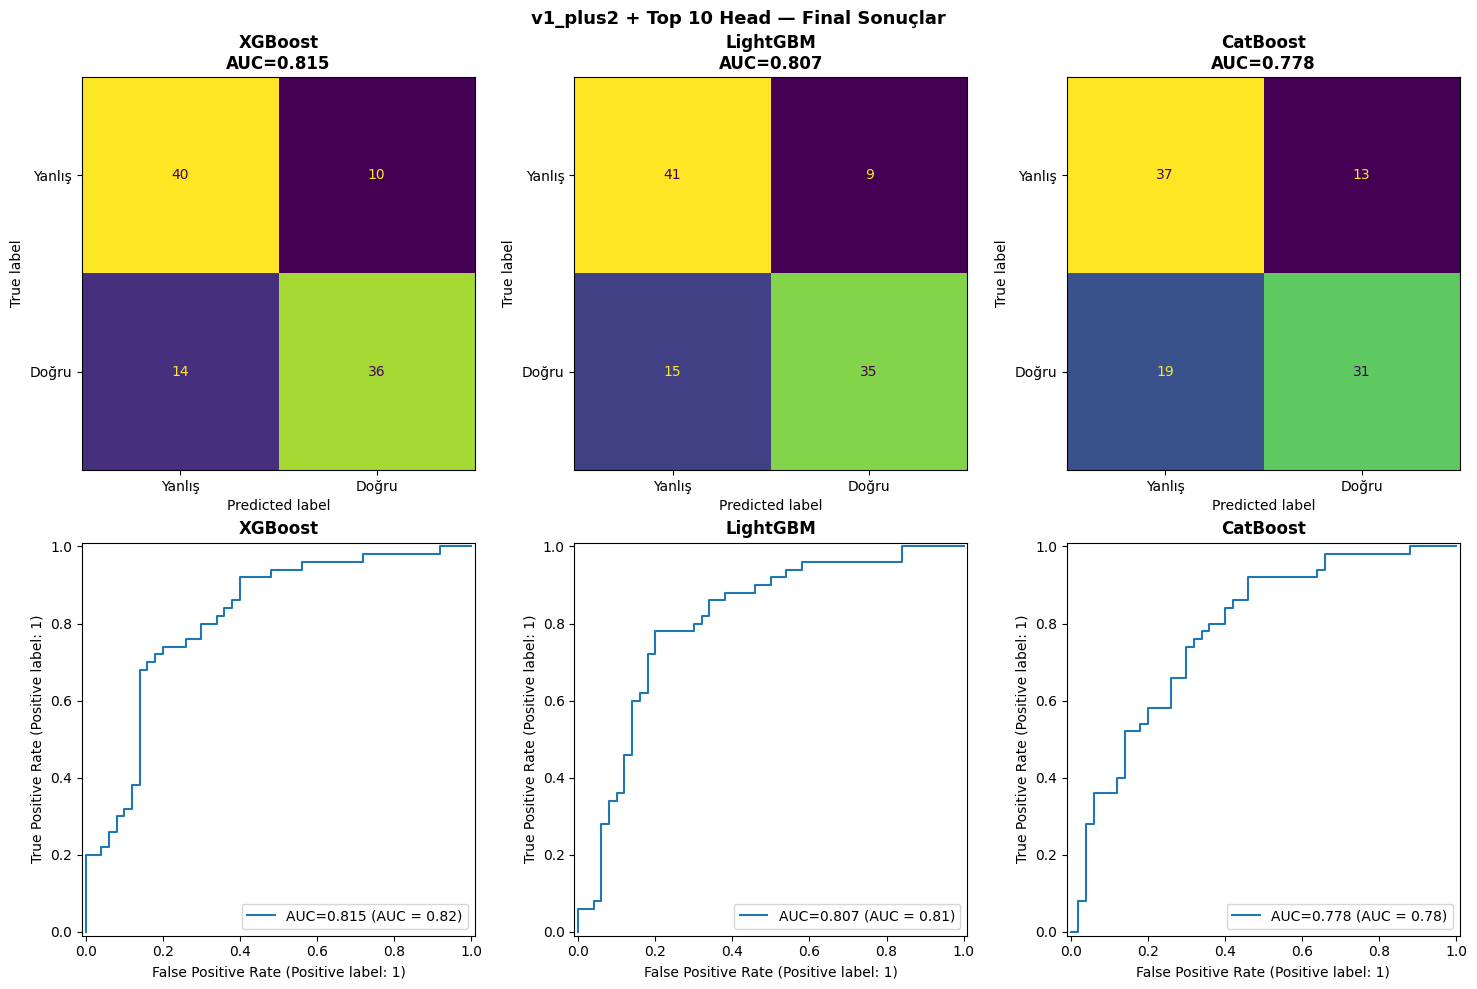

In [45]:
import numpy as np
import os
import pandas as pd
from sklearn.metrics import roc_auc_score, classification_report, log_loss
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

N_FEATURES_PER_HEAD = X_train_v1p2.shape[1] // (42 * 16)
print(f"Özellik per head: {N_FEATURES_PER_HEAD}")  # 28 olmalı

# --- 1. HER HEAD'İ AYRI AYRI TEST ET ---
results_per_head = []
print("\nHer head test ediliyor...")

for layer in range(42):
    for head in range(16):
        start = (layer * 16 + head) * N_FEATURES_PER_HEAD
        end   = start + N_FEATURES_PER_HEAD

        X_tr = X_train_v1p2[:, start:end]
        X_te = X_test_v1p2[:,  start:end]

        m = XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            reg_alpha=2.0, reg_lambda=5.0, min_child_weight=10,
            eval_metric='logloss', random_state=42,
            n_jobs=-1, verbosity=0, early_stopping_rounds=20
        )
        m.fit(X_tr, y_train_v1p2,
              eval_set=[(X_tr, y_train_v1p2), (X_te, y_test_v1p2)],
              verbose=False)

        auc = roc_auc_score(y_test_v1p2, m.predict_proba(X_te)[:, 1])
        results_per_head.append({
            'layer': layer, 'head': head, 'auc': auc,
            'start': start, 'end': end
        })

df_heads_v1p2 = pd.DataFrame(results_per_head).sort_values('auc', ascending=False)
print("\n--- En İyi 10 Head (v1_plus2) ---")
print(df_heads_v1p2.head(10).to_string(index=False))

# --- 2. EN İYİ N HEAD KOMBİNASYONU ---
print("\n--- En İyi N Head Kombinasyonu ---")
best_auc  = 0
best_top_n = 0

for top_n in [5, 10, 20, 30, 40, 50, 60, 80]:
    top_heads = df_heads_v1p2.head(top_n)
    cols = []
    for _, row in top_heads.iterrows():
        cols.extend(range(int(row['start']), int(row['end'])))

    X_tr = X_train_v1p2[:, cols]
    X_te = X_test_v1p2[:,  cols]

    m = XGBClassifier(
        n_estimators=500, max_depth=3, learning_rate=0.03,
        reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
        subsample=0.6, colsample_bytree=0.5,
        eval_metric='logloss', random_state=42,
        n_jobs=-1, verbosity=0, early_stopping_rounds=30
    )
    m.fit(X_tr, y_train_v1p2,
          eval_set=[(X_tr, y_train_v1p2), (X_te, y_test_v1p2)],
          verbose=False)

    auc = roc_auc_score(y_test_v1p2, m.predict_proba(X_te)[:, 1])
    print(f"Top {top_n:2d} head ({len(cols):4d} sütun) → AUC: {auc:.4f}")

    if auc > best_auc:
        best_auc   = auc
        best_top_n = top_n

print(f"\nEn iyi: Top {best_top_n} head → AUC: {best_auc:.4f}")

# --- 3. EN İYİ KOMBİNASYONLA TAM EĞİTİM ---
print(f"\n--- Top {best_top_n} Head ile Tam Eğitim ---")

top_heads = df_heads_v1p2.head(best_top_n)
cols = []
for _, row in top_heads.iterrows():
    cols.extend(range(int(row['start']), int(row['end'])))

X_tr = X_train_v1p2[:, cols]
X_te = X_test_v1p2[:,  cols]

xgb_model = XGBClassifier(
    n_estimators=1000, max_depth=3, learning_rate=0.03,
    subsample=0.6, colsample_bytree=0.5,
    reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
    eval_metric='logloss', random_state=SEED,
    n_jobs=-1, verbosity=0, early_stopping_rounds=30
)

lgb_model = LGBMClassifier(
    n_estimators=1000, max_depth=3, num_leaves=7, learning_rate=0.03,
    subsample=0.6, colsample_bytree=0.5,
    reg_alpha=3.0, reg_lambda=8.0, min_child_weight=15,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)

cat_model = CatBoostClassifier(
    iterations=1000, depth=3, learning_rate=0.03,
    l2_leaf_reg=8.0, auto_class_weights='Balanced',
    early_stopping_rounds=30, random_seed=SEED, verbose=0
)

xgb_model.fit(X_tr, y_train_v1p2,
              eval_set=[(X_tr, y_train_v1p2), (X_te, y_test_v1p2)],
              verbose=False)

lgb_model.fit(X_tr, y_train_v1p2,
              eval_set=[(X_tr, y_train_v1p2), (X_te, y_test_v1p2)],
              eval_names=['Train', 'Test'], eval_metric='binary_logloss',
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

cat_model.fit(X_tr, y_train_v1p2,
              eval_set=(X_te, y_test_v1p2), verbose=False)

# --- 4. GRAFİK ---
xgb_res = xgb_model.evals_result()
lgb_res  = lgb_model.evals_result_
cat_res  = cat_model.get_evals_result()
metric   = list(lgb_res['Train'].keys())[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tr, te, title in zip(
    axes,
    [xgb_res['validation_0']['logloss'],
     lgb_res['Train'][metric],
     cat_res['learn']['Logloss']],
    [xgb_res['validation_1']['logloss'],
     lgb_res['Test'][metric],
     cat_res['validation']['Logloss']],
    ['XGBoost', 'LightGBM', 'CatBoost']
):
    ax.plot(tr, label='Eğitim Hatası', color='blue', linewidth=2)
    ax.plot(te, label='Test Hatası',   color='red',  linewidth=2, linestyle='--')
    gap = te[-1] - tr[-1]
    ax.set_title(f'{title}\n(Son Gap: {gap:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('İterasyon')
    ax.set_ylabel('Log Loss')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

plt.suptitle(f'v1_plus2 + Top {best_top_n} Head', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- 5. SONUÇLAR ---
print("=" * 60)
results_v1p2 = {}
for name, clf in [('XGBoost', xgb_model), ('LightGBM', lgb_model), ('CatBoost', cat_model)]:
    y_pred  = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)[:, 1]
    auc     = roc_auc_score(y_test_v1p2, y_proba)
    ll      = log_loss(y_test_v1p2, y_proba)

    print(f"\n▶ {name}")
    print(classification_report(y_test_v1p2, y_pred, target_names=["Yanlış", "Doğru"]))
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Log Loss : {ll:.4f}")

    results_v1p2[name] = {
        "clf": clf, "y_pred": y_pred,
        "y_proba": y_proba, "auc": auc, "log_loss": ll
    }
print("=" * 60)

# --- 6. CONFUSION MATRIX + ROC CURVE ---
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for col, (name, res) in enumerate(results_v1p2.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_v1p2, res["y_pred"],
        display_labels=["Yanlış", "Doğru"],
        ax=axes[0][col], colorbar=False
    )
    axes[0][col].set_title(f'{name}\nAUC={res["auc"]:.3f}', fontweight='bold')

    RocCurveDisplay.from_predictions(
        y_test_v1p2, res["y_proba"],
        name=f"AUC={res['auc']:.3f}",
        ax=axes[1][col]
    )
    axes[1][col].set_title(name, fontweight='bold')

plt.suptitle(f"v1_plus2 + Top {best_top_n} Head — Final Sonuçlar",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()